# 01 · Data Exploration & Sample Characterization
## NHANES 2017–2020 Women's CKM Phenotyping Project

---

## NHANES 2017–March 2020 Pre-Pandemic | Reproductive Health Module (P_RHQ)

**Author:** Alexandra Velez, OB-GYN (Colombia) | Data Science 
**Module:** P_RHQ — Reproductive Health Questionnaire  
**Analytical Sample:** Women aged 20–44 (primary) | 20–150 (secondary)  
**Last updated:** 2026

---

### Purpose of this notebook

This notebook is the foundation of a multi-notebook pipeline for reproductive 
health feature engineering and cardiovascular-kidney-metabolic (CKM) phenotyping 
in women. P_RHQ is a deceptively complex dataset — 32 variables across 5,314 
participants sounds manageable, but conceals three sources of complexity that must 
be understood before any analysis begins. 

First, extensive skip logic means most variables are 
only administered to specific subgroups — a missing value in this dataset rarely 
means the participant did not answer, it usually means they were never asked. 
For example, all questions about gestational diabetes, delivery counts, and 
macrosomia are only asked of women who confirmed they had been pregnant — a 
woman with NaN in those variables is nulliparous, not unknown.
Second, structural missingness patterns differ fundamentally from random 
missingness and must not be imputed. Third, CDC has deliberately suppressed 
pregnancy and hysterectomy data for women aged 12–19 and 45+ in the public use 
file due to disclosure risk, reducing the analytical sample to women aged 20–44 
only. Each of these constraints is documented and quantified in this notebook 
before a single feature is engineered.

This notebook covers:
1. Data loading and initial inspection
2. NHANES encoding and cleaning strategy
3. Reusable cleaning functions
4. **Sample characterization and skip logic mapping** — who is actually in this data
5. Analytical sample definition and justification
6. Export of the clean, characterized sample for feature engineering in notebook 02

Exploration and engineering are deliberately separated. Rushing into feature 
engineering without fully understanding the data structure, skip logic, and sample 
composition is the most common source of analytic errors in NHANES research. This 
notebook documents every structural discovery that informs downstream decisions.

---

### Why this dataset

**Data source:** NHANES 2017–March 2020 pre-pandemic cycle (P_RHQ).

This cycle was selected deliberately:
- Pandemic-era cycles (2021–2023) have COVID-19-related disruptions in sampling, 
  response rates, and metabolic baselines
- The 2017–2020 pre-pandemic cycle provides complete data collection under 
  traditional NHANES protocols
- It represents a stable population baseline unaffected by pandemic-related 
  metabolic changes or healthcare access disruptions
- The combined 2.5-cycle design restores national representativeness despite 
  the incomplete 2019–2020 data collection

---

### Why reproductive health matters for CKM risk

Standard cardiovascular risk calculators — Pooled Cohort Equations, SCORE2 — 
were developed predominantly in male cohorts and miss female-specific risk signals 
entirely. The 2023 AHA/ACC CKM framework explicitly recognizes adverse pregnancy 
outcomes as cardiovascular risk enhancers, but they remain absent from most clinical 
risk assessments.

The clinical insight driving this project: a 35-year-old woman with a history of 
gestational diabetes and borderline metabolic biomarkers has a fundamentally different 
risk trajectory than a 35-year-old without that history, even if their current lab 
values look identical. GDM reveals underlying insulin resistance years — sometimes 
decades — before conventional screening would detect it.

This pipeline tests whether women with adverse pregnancy outcomes cluster into 
distinct cardiometabolic phenotypes, or appear within existing high-risk phenotypes 
at younger ages — evidence of accelerated progression toward CKM disease.

---

### Important data limitations identified during exploration

1. **Pregnancy data suppressed for women 45+.** The public use file contains 
   complete pregnancy records only for women aged 20–44. CDC suppressed this data 
   for women 45+ due to disclosure risk. The complete file (P_RHQ_R) is available 
   through the NCHS Research Data Center. This limits our primary CKM analysis to 
   reproductive-age women — a meaningful constraint that is also a clinically 
   important intervention window.

2. **This is a 2.5-cycle dataset, not a standard 2-year cycle.** NHANES normally 
   collects data in 2-year cycles. This file combines the complete 2017–2018 cycle 
   with a partial 2019–2020 cycle that was cut short by COVID-19, creating an 
   atypical 2.5-year dataset. This matters because NHANES deliberately oversamples 
   certain groups — older adults, Hispanic and Black populations, and low-income 
   individuals — to ensure they are adequately represented. To correct for this 
   and make estimates representative of the US population as a whole, NHANES 
   provides survey weights that mathematically adjust each participant's 
   contribution to the analysis.

   How to handle this depends on what we are trying to do:

   - **Descriptive statistics** (e.g., "X% of women aged 20–44 have a history 
     of GDM") are population-level claims and require survey weights to be 
     accurate. `WTMECPRP` was used — the full sample MEC examination weight — 
     confirmed as the correct weight for this combined cycle by the CDC P_DEMO 
     codebook, which states explicitly: *"The special sample weights (WTINTPRP, 
     WTMECPRP) should be used for all NHANES 2017-March 2020 pre-pandemic data 
     analyses."* `WTMECPRP` was used specifically (rather than `WTINTPRP`, the 
     interview weight) because P_RHQ was administered at the Mobile Examination 
     Center (MEC), not the home interview. Participants who completed the home 
     interview but did not attend the MEC receive `WTMECPRP = 0` and are 
     excluded from weighted analyses. Correct standard error estimation also 
     requires the masked variance pseudo-PSU (`SDMVPSU`) and pseudo-stratum 
     (`SDMVSTRA`) variables from P_DEMO alongside the weight. Both weighted 
     and unweighted prevalence estimates are reported so the impact of 
     weighting is transparent.

   - **Clustering analysis** asks a different question entirely — not "how 
     common is this pattern in the US population" but "does this pattern exist 
     and what does it look like." For this purpose, survey weights are not only 
     unnecessary but can distort results by artificially upweighting or 
     downweighting observations in ways that obscure natural groupings. 
     Clustering is performed on the unweighted analytical sample.
  
     
3. **P_RHQ contains reproductive history only — no health outcomes.** This module 
   tells us about a woman's pregnancies, menstrual history, and hormone use, but 
   it does not tell us whether she has diabetes, high blood pressure, or kidney 
   disease. To answer CKM questions we need to link this data to other NHANES 
   modules that contain lab results, blood pressure measurements, and body 
   measurements. That linkage is the central task of notebook 03.

4. **All data is self-reported, which introduces recall bias.** Participants were 
   asked to remember medical events — sometimes decades old — during a single 
   interview. A woman may not remember whether she was told she had gestational 
   diabetes, may confuse it with pre-existing diabetes, or may not have been 
   formally diagnosed at all. This means our reproductive features reflect 
   reported history, not verified medical records, and prevalence estimates may 
   be conservative.

---

### Notebook outputs

This notebook produces two outputs consumed by downstream notebooks:

| Output | Description | Used in |
|---|---|---|
| `data/processed/nhanes_clean_sample.csv` | Clean analytical sample with age restriction applied, structural missingness documented, and P_DEMO variables merged (age, race/ethnicity, education, income, survey weights) | Notebooks 02, 03 |
| `data/processed/sample_characterization.csv` | Participant counts by subgroup, skip logic routing, coverage summary, weighted and unweighted prevalence estimates | Reference / methods reporting |

---
## Section 1 · Imports & Setup

In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import os
from IPython.display import display, HTML
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
RAW_DATA_PATH  = Path('../data/raw/P_RHQ.XPT')
DEMO_DATA_PATH = Path('../data/raw/P_DEMO.XPT')
OUTPUT_PATH    = Path('../data/processed/nhanes_clean_sample.csv')
CHAR_PATH      = Path('../data/processed/sample_characterization.csv')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
NHANES_BASE_URL = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_RHQ.htm"

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Setup complete.')
print(f'  P_RHQ path:  {RAW_DATA_PATH}')
print(f'  P_DEMO path: {DEMO_DATA_PATH}')
print(f'  Output path: {OUTPUT_PATH}')

Setup complete.
  P_RHQ path:  ../data/raw/P_RHQ.XPT
  P_DEMO path: ../data/raw/P_DEMO.XPT
  Output path: ../data/processed/nhanes_clean_sample.csv


---
## Section 2 · Data Loading & Initial Exploration

### Data loading

NHANES distributes all its data as **SAS Transport files (.XPT)**, a format 
originally designed for sharing data between statistical software packages. 
Pandas reads these natively via `read_sas()` — no conversion needed.

We load two files in this notebook:

- **P_RHQ.XPT** — the Reproductive Health Questionnaire. Contains 5,314 
  female participants aged 12–150 years and 32 variables covering menstrual 
  history, pregnancy history, surgical history, and hormone therapy use.

- **P_DEMO.XPT** — Demographics and Sample Weights. Contains all 15,560 
  NHANES participants (male and female, all ages) and 29 variables including 
  age, race/ethnicity, education, income, and critically, the survey weights 
  we need for population-level estimates.

Every participant in every NHANES module is identified by **SEQN** — a unique 
respondent sequence number that serves as the key linking variable across all 
modules. A participant's SEQN in P_RHQ will match their SEQN in P_DEMO, 
P_BIOPRO, P_BMX, and every other module in the dataset. This is what makes 
multi-module integration possible in later notebooks.

This linkage was validated immediately after loading — every P_RHQ participant 
must have a matching record in P_DEMO, otherwise the files are from different 
releases and the merge would be invalid.

In [301]:
# ── Load raw data files ────────────────────────────────────────────────────
# P_RHQ: Reproductive Health Questionnaire
df_raw = pd.read_sas(RAW_DATA_PATH, format='xport', encoding='utf-8')
df_raw = df_raw.set_index('SEQN')

# P_DEMO: Demographics and Survey Weights
demo_raw = pd.read_sas(DEMO_DATA_PATH, format='xport', encoding='utf-8')

# ── Basic validation ───────────────────────────────────────────────────────
# Confirm both files loaded and share the same SEQN universe
# df_raw uses SEQN as index — access via .index not ['SEQN']
rhq_seqn  = set(df_raw.index)
demo_seqn = set(demo_raw['SEQN'])  # demo_raw still has SEQN as column

print('=== P_RHQ: Reproductive Health ===')
print(f'  Shape:         {df_raw.shape[0]:,} participants × {df_raw.shape[1]} variables')
print(f'                 (31 variables + SEQN as index = 32 total)')
print(f'  Memory:        {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

print('\n=== P_DEMO: Demographics & Weights ===')
print(f'  Shape:         {demo_raw.shape[0]:,} participants × {demo_raw.shape[1]} variables')
print(f'  Memory:        {demo_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

print('\n=== Cross-file validation ===')
print(f'  P_RHQ SEQNs:               {len(rhq_seqn):,}')
print(f'  P_DEMO SEQNs:              {len(demo_seqn):,}')
print(f'  In P_RHQ but not P_DEMO:   {len(rhq_seqn - demo_seqn):,}')
print(f'  In P_DEMO but not P_RHQ:   {len(demo_seqn - rhq_seqn):,}')

assert rhq_seqn.issubset(demo_seqn), \
    '⚠️ Some P_RHQ participants are missing from P_DEMO — check file versions'
print('\n✓ All P_RHQ participants confirmed present in P_DEMO')

# Expected output:
# P_RHQ SEQNs:             5,314  — females 12+ only
# P_DEMO SEQNs:           15,560  — full sample, all ages and genders
# In P_RHQ but not P_DEMO:     0  — confirms safe merge ✓
# In P_DEMO but not P_RHQ: 10,246 — males + females under 12, not needed

df_raw.head(3)

=== P_RHQ: Reproductive Health ===
  Shape:         5,314 participants × 31 variables
                 (31 variables + SEQN as index = 32 total)
  Memory:        1.4 MB

=== P_DEMO: Demographics & Weights ===
  Shape:         15,560 participants × 29 variables
  Memory:        3.6 MB

=== Cross-file validation ===
  P_RHQ SEQNs:               5,314
  P_DEMO SEQNs:              15,560
  In P_RHQ but not P_DEMO:   0
  In P_DEMO but not P_RHQ:   10,246

✓ All P_RHQ participants confirmed present in P_DEMO


,RHQ010,RHD018,RHQ020,RHQ031,RHD043,RHQ060,RHQ070,RHQ074,RHQ076,RHQ078,...,RHD280,RHQ305,RHQ332,RHQ540,RHQ542A,RHQ542B,RHQ542C,RHQ542D,RHQ554,RHQ570
SEQN,,,,,,,,,,,,,,,,,,,,,
109264.0,12.0,155.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
109266.0,13.0,NaN,NaN,1.0,NaN,NaN,NaN,2.0,2.0,2.0,...,2.0,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
109277.0,11.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The 10,246 participants present in P_DEMO but not P_RHQ are males and 
females under 12 — groups not eligible for the reproductive health 
questionnaire. Their absence from P_RHQ is expected and requires no action.

---
## Section 3 · NHANES Encoding System

The NHANES encoding scheme must be fully understood before touching a single value. 
Mishandling these codes is the most common source of analytic errors in NHANES 
research — treating `9` ("Don't know") as a valid numeric response, for example, 
would introduce phantom values of 9 into age variables, distorting every 
downstream calculation.

### The encoding rules

| Code | Meaning | Action |
|---|---|---|
| `1` | Yes | Keep |
| `2` | No | Keep |
| `7` / `77` / `777` | Refused | → `NaN` |
| `9` / `99` / `999` | Don't know | → `NaN` |
| `7777` / `9999` | Refused / Don't know (4-digit) | → `NaN` |
| `NaN` | Not asked (skip logic) | Keep as `NaN` — it's structural |


#### Sentinel values — a different kind of boundary

For continuous variables (ages, counts), NHANES uses **sentinel values** to 
mark the boundaries of top- and bottom-coded ranges. These are not missing 
values — they are real responses that carry genuine information, just with 
limited precision at the extremes.

**Top-coding** collapses high values into a single maximum code to protect 
participant privacy:
- `11` in RHQ160 = 11 or more pregnancies — a ceiling, not exactly 11
- `5` in RHD167 = 5 or more deliveries — a ceiling, not exactly 5
- `60` in RHQ060 = 60 years or older at last menstrual period

**Bottom-coding** collapses low values into a single minimum code:
- `17` in RHD180/RHD190 = 17 years or younger at first/last live birth
- `19` in RHQ332 = 19 years or younger at oophorectomy

**Clinically meaningful special codes** that are neither missing nor 
top/bottom-coded:
- `0` in RHQ010 = menarche has not yet occurred — primary amenorrhea 
  or normal pre-pubertal status; routes participant to end of section
- `20` in RHQ010 = menarche at 20 years or older — very late menarche, 
  clinically distinct from the main distribution

Each of these requires a deliberate case-by-case decision during feature 
engineering in notebook 02. 

Blanket conversion of unusual numeric values to `NaN` would erase real clinical 
information — a woman with 11 pregnancies would appear to have unknown pregnancy 
history, and a girl whose menarche hasn't started would be indistinguishable from 
one who refused to answer. The cleaning functions in the next section target only 
refused and don't know codes, leaving sentinel values intact.

One additional data quality issue specific to SAS XPT files is addressed in 
Section 4 before any cleaning is applied — true zero values in three variables 
are stored as a near-zero floating point artifact due to a known SAS export 
precision issue. This is detected and corrected before the cleaning functions 
run, ensuring zero values are never misclassified as missing.

---
## Section 4 · Data Quality: SAS XPT Artifact Detection & Fix

SAS Transport (.XPT) files have a known floating point precision issue — true 
zero values are sometimes exported as an extremely small near-zero number 
(5.397605e-79) rather than exactly 0.0. This artifact very often passes silently through 
standard cleaning pipelines because it is not in the NHANES missing value code 
set, is not equal to zero under standard comparison, and does not trigger any 
dtype warnings. Left uncorrected, it causes clinically meaningful zero values 
to be misclassified — either treated as missing or miscounted — introducing 
systematic bias into any downstream analysis.

This section defines a reusable scan function, runs it across all 31 P_RHQ 
variables immediately after loading, and applies a targeted fix before any 
cleaning or analysis takes place. This is a mandatory step for any analysis 
based on SAS XPT files.

**Why this must run before cleaning:**

The NHANES cleaning functions defined in Section 5 target specific missing 
value codes (7, 9, 77, 99, etc.). They do not touch near-zero artifact values. 
If the artifact fix runs after cleaning, the artifact values persist into the 
cleaned dataset and propagate silently into all subsequent analyses. Running 
the fix first guarantees that by the time cleaning functions are applied, every 
zero in the dataset is a true zero.

In [302]:
# ── SAS XPT artifact detection ─────────────────────────────────────────────
# SAS Transport files sometimes store true zero values as ~5.397605e-79
# due to floating point precision limitations in the XPT export format.
# This function scans all numeric columns for sub-epsilon values that
# are functionally zero but fail == 0 comparison.

EPSILON = 1e-10  # threshold below which non-zero values are treated as zero
                 # 5.397605e-79 is ~69 orders of magnitude below this threshold
                 # the smallest valid value in P_RHQ is 0 (exact zero)
                 # the next smallest is 6 (age at menarche)

def scan_sas_artifacts(df, epsilon=EPSILON):
    """
    Scan a dataframe for SAS XPT floating point artifacts.

    In SAS XPT files, true zeros are sometimes exported as a very small
    near-zero number (~5.397605e-79) due to floating point precision
    limitations in the XPORT format. These values:
      - Are not equal to zero under standard == comparison
      - Are not in the NHANES missing value code set
      - Persist standard cleaning pipelines undetected
      - Cause clinically meaningful zero values to be miscounted

    Parameters
    ----------
    df      : pd.DataFrame — dataframe loaded from a SAS XPT file
    epsilon : float — threshold below which non-zero values are suspect
                      default 1e-10 is safely above any artifact value
                      and safely below any valid small numeric value

    Returns
    -------
    dict — {column_name: count} for all columns with artifact values
           empty dict if no artifacts detected
    """
    affected = {}
    for col in df.select_dtypes(include='number').columns:
        mask = (
            df[col].notna() &
            (df[col].abs() < epsilon) &
            (df[col] != 0.0)
        )
        n = mask.sum()
        if n > 0:
            affected[col] = n
    return affected


print('✓ scan_sas_artifacts() defined')
print(f'  Epsilon threshold: {EPSILON}')
print(f'  Applies to: all numeric columns')
print(f'  Detects: non-null values where 0 < |value| < {EPSILON}')

✓ scan_sas_artifacts() defined
  Epsilon threshold: 1e-10
  Applies to: all numeric columns
  Detects: non-null values where 0 < |value| < 1e-10


In [303]:
# ── Run artifact scan on P_RHQ ─────────────────────────────────────────────
print('=== SAS XPT Artifact Scan — P_RHQ ===\n')

artifacts = scan_sas_artifacts(df_raw)

if artifacts:
    print(f'  ⚠️  Artifacts detected in {len(artifacts)} column(s):\n')
    print(f'  {"Column":<12} {"N affected":>10}  {"Clinical meaning of zero"}')
    print(f'  {"─"*12} {"─"*10}  {"─"*40}')
    for col, n in artifacts.items():
        print(f'  {col:<12} {n:>10,}  {KEY_VARS.get(col, "see codebook")}')
else:
    print('  ✓ No artifacts detected — all zero values are exact 0.0')

print(f'\n  Total artifact values: {sum(artifacts.values()):,}')
print(f'  Total columns scanned: {len(df_raw.select_dtypes(include="number").columns):,}')

=== SAS XPT Artifact Scan — P_RHQ ===

  ⚠️  Artifacts detected in 3 column(s):

  Column       N affected  Clinical meaning of zero
  ──────────── ──────────  ────────────────────────────────────────
  RHQ010               62  Age at first menstrual period
  RHD167              173  Total number of deliveries / parity
  RHQ171               18  Number of deliveries resulting in live birth

  Total artifact values: 253
  Total columns scanned: 31


Three variables contain artifact values — all storing clinically meaningful 
zero values as 5.397605e-79:

| Variable | N affected | Clinical meaning of zero |
|---|---|---|
| RHQ010 | 62 | Menarche not yet started → routes to end of section |
| RHD167 | 173 | Nulliparous — pregnant but no full term deliveries |
| RHQ171 | 18 | No live births — all deliveries ended in fetal or neonatal loss |

All three are count or age variables where zero carries distinct clinical 
meaning. Treating these as missing would silently exclude nulliparous women 
from parity-based features, misclassify women with no live births, and 
incorrectly route 62 participants through the menarche gate variable. The 
fix is applied below using `numpy.where()`, which creates a new array rather 
than modifying values in place — ensuring reliable replacement regardless of 
pandas version or copy semantics.

In [304]:
# ── Apply SAS artifact fix ─────────────────────────────────────────────────
# Replace all sub-epsilon values with exactly 0.0
# numpy.where() is used rather than .loc assignment because pandas copy
# semantics can cause .loc replacements to silently fail for near-zero values

print('=== Applying SAS Artifact Fix ===\n')

artifact_cols = list(artifacts.keys())

for col in artifact_cols:
    df_raw[col] = np.where(
        df_raw[col].notna() & (df_raw[col].abs() < EPSILON),
        0.0,
        df_raw[col]
    )

# ── Validate fix ───────────────────────────────────────────────────────────
print(f'  {"Column":<12} {"Zeros before":>13} {"Zeros after":>12} {"Artifacts remaining":>20}')
print(f'  {"─"*12} {"─"*13} {"─"*12} {"─"*20}')

for col, n_before in artifacts.items():
    n_zeros     = (df_raw[col] == 0.0).sum()
    n_remaining = (
        df_raw[col].notna() &
        (df_raw[col].abs() < EPSILON) &
        (df_raw[col] != 0.0)
    ).sum()
    print(f'  {col:<12} {n_before:>13,} {n_zeros:>12,} {n_remaining:>20,}')

# Confirm no artifacts remain anywhere in the file
remaining = scan_sas_artifacts(df_raw)
assert len(remaining) == 0, \
    f'Artifacts still present after fix: {remaining}'

print(f'\n✓ All artifact values replaced with exactly 0.0')
print(f'✓ scan_sas_artifacts() confirms zero artifacts remaining')

=== Applying SAS Artifact Fix ===

  Column        Zeros before  Zeros after  Artifacts remaining
  ──────────── ───────────── ──────────── ────────────────────
  RHQ010                  62           62                    0
  RHD167                 173          173                    0
  RHQ171                  18           18                    0

✓ All artifact values replaced with exactly 0.0
✓ scan_sas_artifacts() confirms zero artifacts remaining


The fix is confirmed — all three variables now contain exact 0.0 values 
where the artifact previously appeared, and a re-scan of all columns finds 
no remaining sub-epsilon values.

**Applying the fix to `df_raw` directly** ensures that every dataframe 
derived from it — `df_clean`, `df_full`, `df_analytical` — inherits the 
corrected values automatically. No downstream fix cells are needed.

In [305]:
# ── Scan demo_raw for artifacts as well ───────────────────────────────────
print('=== SAS XPT Artifact Scan — P_DEMO ===\n')

demo_artifacts = scan_sas_artifacts(demo_raw)

if demo_artifacts:
    print(f'  ⚠️  Artifacts detected in {len(demo_artifacts)} column(s):\n')
    print(f'  {"Column":<12} {"N affected":>10}')
    print(f'  {"─"*12} {"─"*10}')
    for col, n in demo_artifacts.items():
        print(f'  {col:<12} {n:>10,}')

    # Apply fix to demo_raw
    for col in demo_artifacts:
        demo_raw[col] = np.where(
            demo_raw[col].notna() & (demo_raw[col].abs() < EPSILON),
            0.0,
            demo_raw[col]
        )

    # Validate
    remaining = scan_sas_artifacts(demo_raw)
    assert len(remaining) == 0, \
        f'Artifacts still present in demo_raw: {remaining}'
    print(f'\n✓ All artifacts fixed in demo_raw')
else:
    print('  ✓ No artifacts detected in P_DEMO')

=== SAS XPT Artifact Scan — P_DEMO ===

  ⚠️  Artifacts detected in 4 column(s):

  Column       N affected
  ──────────── ──────────
  RIDAGEYR            574
  RIDAGEMN             57
  WTMECPRP          1,260
  INDFMPIR            142

✓ All artifacts fixed in demo_raw


Both NHANES source files are distributed as SAS Transport (.XPT) files and 
both require artifact scanning before any analysis begins. The scan and fix 
are applied to P_RHQ and P_DEMO independently — P_DEMO is scanned here 
rather than at load time because the artifact fix must precede any variable 
selection, merging, or analysis that uses values from either file.

The P_DEMO scan revealed artifacts in four variables — two of which are 
critical to this analysis:

- **WTMECPRP** (1,260 values) — the MEC examination survey weight. Zero is 
  a valid and meaningful value identifying interview-only participants who 
  did not attend the MEC and are excluded from examination-based analyses. 
  Had these artifact zeros gone undetected, the `WTMECPRP > 0` filter used 
  throughout this notebook would have silently misclassified 1,260 
  interview-only participants as having valid examination weights.

- **RIDAGEYR** (574 values) — participant age at screening. Zero indicates 
  participants under one year old — not present in P_RHQ but correct to fix 
  in the source file before any merge.

- **INDFMPIR** (142 values) — poverty income ratio. Zero indicates household 
  income at exactly zero, a clinically meaningful value for low-income 
  analyses.

- **RIDAGEMN** (57 values) — age in months, recorded only for participants 
  aged 0–24 months. Not relevant for this analysis but fixed for completeness.

The fix is applied to `demo_raw` directly — all dataframes derived from it 
will inherit the corrected values automatically.

**For future reference:** any NHANES module distributed as a SAS XPT file 
should be scanned with `scan_sas_artifacts()` immediately after loading. 
The affected variables will differ by module, but the artifact value 
(5.397605e-79) is consistent across files because it originates in the 
SAS XPT export process, not in the data itself.

In [306]:
# ── Final cross-file artifact validation ───────────────────────────────────
print('=== Final Artifact Scan — Both Files ===\n')

rhq_remaining  = scan_sas_artifacts(df_raw)
demo_remaining = scan_sas_artifacts(demo_raw)

assert len(rhq_remaining)  == 0, f'Artifacts in df_raw: {rhq_remaining}'
assert len(demo_remaining) == 0, f'Artifacts in demo_raw: {demo_remaining}'

print('  P_RHQ  (df_raw):   ✓ No artifacts remaining')
print('  P_DEMO (demo_raw): ✓ No artifacts remaining')
print('\n✓ Both source files confirmed artifact-free')
print('  All dataframes derived from these files inherit correct zero values')

=== Final Artifact Scan — Both Files ===

  P_RHQ  (df_raw):   ✓ No artifacts remaining
  P_DEMO (demo_raw): ✓ No artifacts remaining

✓ Both source files confirmed artifact-free
  All dataframes derived from these files inherit correct zero values


## Section 5 · Variable Dictionary & Coverage

### Variable dictionary

NHANES variable codes (RHQ010, RHD018, etc.) are opaque to anyone not already familiar with the module. To improve readability throughout the notebook, a project-specific data dictionary (KEY_VARS) was maintained, mapping each P_RHQ variable code to its plain-language description. Each variable name in the coverage table links directly to its CDC codebook entry for full documentation including question text, response codes, and skip patterns.

The complete dictionary was built by cross-referencing the CDC codebook at: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_RHQ.htm

See data/README_DATA.md for the full variable reference including encoding details, top-coded values, and analytic decisions associated with each variable.

The column list below confirms the file matches CDC codebook documentation — any discrepancy would indicate a file version mismatch.

In [307]:
print(df_raw.columns.tolist())

['RHQ010', 'RHD018', 'RHQ020', 'RHQ031', 'RHD043', 'RHQ060', 'RHQ070', 'RHQ074', 'RHQ076', 'RHQ078', 'RHQ131', 'RHD143', 'RHQ160', 'RHQ162', 'RHD167', 'RHQ171', 'RHQ172', 'RHD180', 'RHD190', 'RHQ197', 'RHQ200', 'RHD280', 'RHQ305', 'RHQ332', 'RHQ540', 'RHQ542A', 'RHQ542B', 'RHQ542C', 'RHQ542D', 'RHQ554', 'RHQ570']


In [308]:
KEY_VARS = {
    # SEQN removed — now serves as the dataframe index, not a column

    # Menstrual history
    'RHQ010':  'Age at first menstrual period',                   # 0=not yet started, 6-19=exact, 20=20 or older
    'RHD018':  'Estimated age at menarche in months — divide by 12 before use',  # 103-191=exact
    'RHQ020':  'Age range at first menstrual period - ordinal',   # 1=<10, 2=10-12, 3=13-15, 4=16+
    'RHQ031':  'Had regular periods in past 12 months',           # 1=Yes, 2=No
    'RHD043':  'Reason for no periods in past 12 months',         # 1=Pregnancy, 2=Breastfeeding, 3=Hysterectomy, 7=Menopause, 9=Other
    'RHQ060':  'Age at last menstrual period',                    # 19=19 or under, 20-59=exact, 60=60 or older
    'RHQ070':  'Age range at last menstrual period - ordinal',    # 1=<30, 2=30-34, 3=35-39, 4=40-44, 5=45-49, 6=50-54, 7=55+

    # Infertility & pelvic history
    'RHQ074':  'Tried at least 1 year to become pregnant without success',  # 1=Yes, 2=No
    'RHQ076':  'Seen a doctor because unable to become pregnant',           # 1=Yes, 2=No
    'RHQ078':  'Ever treated for pelvic infection / PID',                  # 1=Yes, 2=No

    # Pregnancy history & outcomes
    # Variables follow questionnaire order — RHQ162 is asked immediately
    # after gravidity as part of the pregnancy history sequence
    'RHQ131':  'Ever been pregnant',                              # 1=Yes, 2=No
    'RHD143':  'Currently pregnant',                              # 1=Yes, 2=No
    'RHQ160':  'Total number of pregnancies / gravidity',         # 1-10=exact, 11=11 or more
    'RHQ162':  'Gestational diabetes during pregnancy',           # 1=Yes, 2=No, 3=Borderline → coded Yes in notebook 02
    'RHD167':  'Total number of deliveries / parity',             # 0-4=exact, 5=5 or more
    'RHQ171':  'Number of deliveries resulting in live birth',    # 0-4=exact, 5=5 or more
    'RHQ172':  'Any baby weighed 9 lbs or more / macrosomia',    # 1=Yes, 2=No
    'RHD180':  'Age at first live birth',                         # 17=17 or younger, 18-43=exact, 45=45 or older
    'RHD190':  'Age at last live birth',                          # 17=17 or younger, 18-44=exact, 45=45 or older
    'RHQ197':  'Months since last baby',                          # 1=1 month or less, 2-24=exact
    'RHQ200':  'Currently breastfeeding a child',                 # 1=Yes, 2=No

    # Surgical history
    'RHD280':  'Had a hysterectomy',                              # 1=Yes, 2=No
    'RHQ305':  'Had both ovaries removed',                        # 1=Yes, 2=No
    'RHQ332':  'Age when both ovaries removed',                   # 19=19 or under, 22-59=exact, 60=60 or older

    # Hormone therapy
    'RHQ540':  'Ever used female hormones any form - screening question',  # 1=Yes, 2=No
    'RHQ542A': 'Hormone therapy form used: pills',                # 10=Yes
    'RHQ542B': 'Hormone therapy form used: patches',              # 11=Yes
    'RHQ542C': 'Hormone therapy form used: cream/suppository/injection',  # 12=Yes
    'RHQ542D': 'Hormone therapy form used: other',                # 13=Yes
    'RHQ554':  'Ever used estrogen-only hormone pills e.g. Premarin',    # 1=Yes, 2=No
    'RHQ570':  'Ever used estrogen/progestin combo pills e.g. Prempro',  # 1=Yes, 2=No
}


In [309]:
available    = [v for v in KEY_VARS if v in df_raw.columns]
missing_vars = [v for v in KEY_VARS if v not in df_raw.columns]

# Coherence check — should be 32 available, 0 missing if KEY_VARS is correctly aligned
print(f'Available key variables : {len(available)}')
print(f'Not in this release     : {len(missing_vars)}')

if missing_vars:
    print('\n⚠️  KEY_VARS contains variables absent from the file.')
    print('This likely means KEY_VARS needs updating or the wrong XPT was loaded.')
    print('\nMissing variables:')
    for v in missing_vars:
        label = KEY_VARS.get(v, 'See codebook')
        url   = f"{NHANES_BASE_URL}#{v}"
        print(f'  {v:<12} — {label}')
        print(f'               {url}')
else:
    print('\n✓ All KEY_VARS variables confirmed present in file.')

df = df_raw[available].copy()
print(f'\nWorking dataframe shape: {df.shape}')

# Confirm shape matches expectation from codebook
assert df.shape == (5314, 31), \
    f'Unexpected shape {df.shape} — expected (5314, 31). SEQN is index, 31 variables remaining.'
print('✓ Shape confirmed: 5,314 participants × 31 variables')

Available key variables : 31
Not in this release     : 0

✓ All KEY_VARS variables confirmed present in file.

Working dataframe shape: (5314, 31)
✓ Shape confirmed: 5,314 participants × 31 variables


In [310]:
rows = []
for col in df.columns:
    n_missing   = df[col].isna().sum()
    pct_present = 100 * (1 - n_missing / len(df))
    label       = KEY_VARS.get(col, 'See codebook')
    url         = f"{NHANES_BASE_URL}#{col}"

    if pct_present >= 80:
        color = '#d4edda'
    elif pct_present >= 40:
        color = '#fff3cd'
    else:
        color = '#f8d7da'

    rows.append(
        f'<tr style="background-color:{color}">'
        f'<td style="padding:6px"><a href="{url}" target="_blank"><code>{col}</code></a></td>'
        f'<td style="padding:6px">{label}</td>'
        f'<td style="padding:6px; text-align:right">{pct_present:.1f}%</td>'
        f'<td style="padding:6px; text-align:right">{n_missing:,}</td>'
        f'</tr>'
    )

html = f'''
<h4 style="font-family:sans-serif; margin-bottom:6px">
    P_RHQ Variable Coverage — {len(df):,} participants × {len(df.columns)} variables
</h4>
<table style="border-collapse:collapse; font-size:13px; width:100%">
  <thead>
    <tr style="background-color:#343a40; color:white">
      <th style="padding:8px; text-align:left">Variable</th>
      <th style="padding:8px; text-align:left">Description</th>
      <th style="padding:8px; text-align:right">% Present</th>
      <th style="padding:8px; text-align:right">N Missing</th>
    </tr>
  </thead>
  <tbody>{''.join(rows)}</tbody>
</table>
<p style="font-size:11px; color:gray; margin-top:6px">
  🟢 ≥80% present &nbsp; 🟡 40–80% &nbsp; 🔴 &lt;40% &nbsp;|&nbsp;
  Variable names link directly to CDC codebook &nbsp;|&nbsp;
  Missing values reflect both NHANES skip logic and true non-response — 
  see Section 5 for detailed breakdown
</p>
'''

display(HTML(html))

Variable,Description,% Present,N Missing
RHQ010,Age at first menstrual period,92.8%,382
RHD018,Estimated age at menarche in months — divide by 12 before use,13.8%,"4,582"
RHQ020,Age range at first menstrual period - ordinal,0.9%,"5,264"
RHQ031,Had regular periods in past 12 months,91.6%,444
RHD043,Reason for no periods in past 12 months,42.8%,"3,039"
RHQ060,Age at last menstrual period,43.3%,"3,014"
RHQ070,Age range at last menstrual period - ordinal,1.8%,"5,220"
RHQ074,Tried at least 1 year to become pregnant without success,53.4%,"2,478"
RHQ076,Seen a doctor because unable to become pregnant,53.4%,"2,478"
RHQ078,Ever treated for pelvic infection / PID,53.4%,"2,478"


### Variable coverage and structural missingness

Coverage varies dramatically and non-randomly across the 32 variables. Before interpreting any missing value as a data quality problem, the source of missingness must be identified. In NHANES, most missingness is structural — it tells us something about the participant, not about data collection failure.

#### Structural skip logic:

Women who were never pregnant are not asked about GDM, macrosomia, or delivery counts → NaN in RHQ162, RHD167, RHQ171, RHQ172 means nulliparous, not unknown. RHQ131 (ever been pregnant) is the gate variable — women who answered No, Refused, or Don't Know were routed directly to RHD280, bypassing all pregnancy questions.
Pre-menopausal women are not asked their menopause age → NaN in RHQ060 means still menstruating, not missing data.
Women who answered No to RHQ540 (ever used hormones) were routed to end of section → RHQ542A–D coverage of 9.7% / 1.6% / 3.2% / 0.2% reflects only the 675 women who said Yes to RHQ540, not non-response.
62 participants with RHQ010 = 0 (menarche not yet started) were routed to end of section — their NaN values in all subsequent variables are structural.
Identical coverage as a skip logic signature:

RHQ074, RHQ076, and RHQ078 (infertility and pelvic history) all show exactly 53.4% coverage with identical missing counts. This is not a coincidence — they are asked as a sequential block to women aged 18–59 only. Identical coverage across a group of variables is a reliable indicator of shared skip logic.

#### An important data restriction beyond skip logic:

The CDC analytic notes state explicitly: "Select variables related to pregnancy and hysterectomy have been excluded from this public use data file for those aged 12–19 years and over 44 years due to disclosure risks." This means data suppression affects both ends of the age range — teenagers and women over 44 are both missing pregnancy and hysterectomy data, not because they weren't asked, but because CDC removed it from the public file to protect participant privacy.

For researchers needing the complete dataset across all ages, the restricted file (P_RHQ_R) is available through the NCHS Research Data Center via a formal application process.

#### Variables too sparse for clustering features:

RHQ197 (4.5%) and RHQ200 (4.4%) — months since last baby and breastfeeding status, asked only of women aged 20–44 who delivered in the past 2 years. Useful as exclusion flags but not as clustering features.
RHQ332 (8.9%) — age at oophorectomy, very sparse despite RHQ305 (had both ovaries removed) being at 76%. The gap reflects women who said Yes to oophorectomy but could not recall the age. Retained for descriptive purposes only.
RHQ542B–D (under 4%) — specific hormone therapy forms beyond pills. Too sparse for individual clustering features — will be combined into a composite hormone therapy type variable in notebook 02.
RHD018 (13.8%) — estimated menarche age in months, asked of teenagers only (12–19). Sparse by design, used only to supplement RHQ010 where exact age is unknown.
The fundamental rule this establishes:

Most missing values in this dataset must not be imputed with column means or medians. Doing so would assign pregnancy history to women who were never pregnant, menopause ages to women who are still menstruating, and hormone therapy data to women who were never asked. The missingness itself is data and must be preserved as NaN throughout the analysis.



---
## Section 6 · Cleaning Functions & Unit Tests

Four reusable functions are defined here to handle the most common NHANES 
data preparation tasks. Defining them once keeps the rest of the notebook 
free of scattered replacement logic and ensures NHANES missing value codes 
are handled identically across every variable.

Note that the SAS XPT artifact fix in Section 4 runs before these functions 
are applied — by the time cleaning begins, all zero values in the dataset 
are exact 0.0 and will not be affected by any of the functions below.

**Function inventory:**

- `clean_nhanes_col()` — replaces all refused and don't know codes with 
  NaN. This is the only function applied universally across all variables 
  in Section 7. It deliberately does not touch sentinel values (top-coded 
  counts, bottom-coded ages) or zero values — those require case-by-case 
  decisions during feature engineering in notebook 02.

- `recode_yes_no()` — converts NHANES binary coding (1=Yes, 2=No) to 
  (1.0=Yes, 0.0=No, NaN=missing). Returns float so NaN can coexist with 
  valid values. Applied locally in this notebook for prevalence calculations 
  only — permanent recoding of all binary variables is deferred to notebook 02.

- `label_yes_no()` — converts binary coding to human-readable Yes/No strings 
  for exploration and crosstabs where readability matters more than 
  modeling-ready format.

- `ordinal_midpoint()` — converts NHANES ordinal range codes to numeric 
  midpoints. Defined here for completeness — coverage analysis in Section 6 
  confirms that the two variables where this applies (RHQ020, RHQ070) are 
  so sparse (under 1.1%) that midpoint recovery will have negligible impact 
  on coverage.

In [311]:
# ── NHANES missing-value codes ─────────────────────────────────────────────
NHANES_MISSING_BINARY = {7, 9}              # for Yes/No variables
NHANES_MISSING_2DIGIT = {77, 99}            # for 2-digit codes
NHANES_MISSING_3DIGIT = {777, 999}          # for 3-digit codes
NHANES_MISSING_4DIGIT = {7777, 9999}        # for 4-digit codes

ALL_NHANES_MISSING = (
    NHANES_MISSING_BINARY |
    NHANES_MISSING_2DIGIT |
    NHANES_MISSING_3DIGIT |
    NHANES_MISSING_4DIGIT
)

def clean_nhanes_col(series: pd.Series) -> pd.Series:
    """
    Replace all NHANES 'Refused' and 'Don't know' codes with NaN.
    Works on both integer and float dtypes.
    """
    return series.replace(list(ALL_NHANES_MISSING), np.nan)


def recode_yes_no(series: pd.Series) -> pd.Series:
    """
    Convert NHANES binary coding (1=Yes, 2=No) to (1.0=Yes, 0.0=No, NaN=missing).
    Returns float so NaN can be represented alongside valid values.
    """
    cleaned = clean_nhanes_col(series)
    return cleaned.map({1.0: 1.0, 2.0: 0.0})


def label_yes_no(series: pd.Series) -> pd.Series:
    """
    Convert NHANES binary coding to human-readable labels.
    Useful for exploration and crosstabs.
    """
    cleaned = clean_nhanes_col(series)
    return cleaned.map({1.0: 'Yes', 2.0: 'No'})


def ordinal_midpoint(series: pd.Series, midpoint_map: dict) -> pd.Series:
    """
    Convert NHANES ordinal range codes to numeric midpoints.
    Useful for RHQ020 (menarche range) and RHQ070 (menopause range)
    when exact ages are unavailable.

    Example midpoint_map for RHQ070:
        {1: 28, 2: 32, 3: 37, 4: 42, 5: 47, 6: 52, 7: 57}
    """
    cleaned = clean_nhanes_col(series)
    return cleaned.map(midpoint_map)


print(f'✓ Cleaning functions defined.')
print(f'  Missing codes covered: {sorted(ALL_NHANES_MISSING)}')

# ── Quick unit tests ────────────────────────────────────────────────────────
# Verify functions behave correctly before applying them to real data
_test = pd.Series([1.0, 2.0, 7.0, 9.0, 77.0, 99.0, np.nan])

assert clean_nhanes_col(_test).isna().sum() == 5, \
    'clean_nhanes_col failed — expected 5 NaNs (7, 9, 77, 99 → NaN plus original NaN)'
assert recode_yes_no(_test).tolist()[:2] == [1.0, 0.0], \
    'recode_yes_no failed — expected [1.0, 0.0] for first two values'
assert label_yes_no(_test).tolist()[:2] == ['Yes', 'No'], \
    'label_yes_no failed — expected [Yes, No] for first two values'

print('✓ Unit tests passed — functions validated on synthetic data.')
del _test # clean up test variable

✓ Cleaning functions defined.
  Missing codes covered: [7, 9, 77, 99, 777, 999, 7777, 9999]
✓ Unit tests passed — functions validated on synthetic data.


In [312]:
# Demonstrate the cleaning on RHQ131 (Ever pregnant)
# This validates our cleaning functions before applying them to all variables
# RHQ131 was chosen because it is the most consequential gate variable in the
# module — its response determines whether a woman is asked any pregnancy questions

print('=== RHQ131: Ever Pregnant — before cleaning ===')
print(df_raw['RHQ131'].value_counts(dropna=False).sort_index())
# Expected from codebook:
#   1.0 → 3,412  (Yes)
#   2.0 → 640    (No)
#   7.0 → 4      (Refused)
#   9.0 → 1      (Don't know)
#   NaN → 1,257  (Missing — includes 905 teenagers never asked this question)

print('\n=== After cleaning ===')
cleaned = recode_yes_no(df_raw['RHQ131'])
print(cleaned.value_counts(dropna=False))
# Expected after cleaning:
#   1.0 → 3,412  (Yes)
#   0.0 → 640    (No)
#   NaN → 1,262  (1,257 structural + 4 Refused + 1 Don't know)

# Programmatic checks
assert not cleaned.isin([7, 9, 77, 99]).any(), \
    "Cleaning failed — refused/don't know codes still present"
assert cleaned.value_counts()[1.0] == 3412, \
    "Unexpected count for Yes — check source data matches codebook"
assert cleaned.value_counts()[0.0] == 640, \
    "Unexpected count for No — check source data matches codebook"
assert cleaned.isna().sum() == 1262, \
    "Unexpected NaN count — expected 1,257 structural + 4 Refused + 1 Don't know"

print('\n✓ Validation passed — counts match CDC codebook exactly.')
print(f'  Yes (1.0):  {cleaned.value_counts()[1.0]:,}')
print(f'  No  (0.0):  {cleaned.value_counts()[0.0]:,}')
print(f'  NaN:        {cleaned.isna().sum():,}')

# Output interpretation:
# 1,262 NaN after cleaning decomposes as:
#   905  — teenagers (12-19) never asked RHQ131 (age restriction)
#   352  — adults with structural NaN (not asked for other reasons)  
#     4  — Refused
#     1  — Don't know
# ─────
# 1,262  total
#
# The 905 teenagers and the 5 refused/don't know responses
# are fundamentally different types of missingness —
# this distinction is formalized in Section 5.

=== RHQ131: Ever Pregnant — before cleaning ===
RHQ131
1.0    3412
2.0     640
7.0       4
9.0       1
NaN    1257
Name: count, dtype: int64

=== After cleaning ===
RHQ131
1.0    3412
NaN    1262
0.0     640
Name: count, dtype: int64

✓ Validation passed — counts match CDC codebook exactly.
  Yes (1.0):  3,412
  No  (0.0):  640
  NaN:        1,262


This quick check confirms the cleaning functions work as expected. Refused (7) 
and Don't know (9) responses are merged into `NaN`, while valid 1/2 responses 
map cleanly to 1.0/0.0 (Yes/No).

## Section 7 · Apply Cleaning Functions

Cleaning is now applied systematically across all variables of interest. As 
established in Section 3, only refused and don't know codes are replaced — 
sentinel values such as top-coded counts and bottom-coded ages are left intact 
for deliberate handling in notebook 02.

In [313]:
# ── Apply cleaning to all columns ──────────────────────────────────────────
df_clean = df.copy()

# All columns get NHANES missing codes replaced
# Note: SEQN is now the index so it is no longer a column — no risk of cleaning it
for col in df_clean.columns:
    df_clean[col] = clean_nhanes_col(df_clean[col])

print(f'✓ Missing-value cleaning applied to {df_clean.shape[1]} columns.')
print(f'  Shape: {df_clean.shape}')

# ── Data type check ────────────────────────────────────────────────────────
# After cleaning, all columns should be float64
# Integer columns cannot hold NaN — pandas upcasts automatically
non_float = [c for c in df_clean.columns if df_clean[c].dtype != 'float64']
if non_float:
    print(f'\n⚠️  {len(non_float)} columns not float64 after cleaning: {non_float}')
else:
    print('✓ All columns confirmed float64 — NaN coexistence verified.')

# ── Sparsity check ─────────────────────────────────────────────────────────
# 10% threshold is a practical judgment for clustering:
# variables with fewer than ~530 non-missing values (10% of 5,314) provide
# insufficient signal for meaningful cluster separation and risk distorting
# distance-based algorithms through excessive imputation or exclusion
coverage = df_clean.notna().sum() / len(df_clean) * 100
sparse   = coverage[coverage < 10].sort_values()

if len(sparse) > 0:
    print(f'\n⚠️  {len(sparse)} variables below 10% coverage — low utility for clustering:')
    for col, pct in sparse.items():
        label = KEY_VARS.get(col, col)
        print(f'  {col:<12} {pct:4.1f}%  {label}')
    print('\n  Retained for descriptive purposes but excluded from clustering')
    print('  features unless otherwise justified in notebook 02.')
else:
    print('\n✓ All variables above 10% coverage threshold.')

    # Output interpretation:
# RHQ020 (0.9%) and RHQ070 (1.1%) — ordinal fallback variables,
#   asked only when exact age was refused/unknown. Extreme sparsity
#   confirms ordinal_midpoint() will have minimal coverage impact.
#
# RHQ542A-D — all sparse by design, gated behind RHQ540 (ever used
#   hormones, n=675). Will be combined into HRT_Type composite in
#   notebook 02 rather than used as individual features.
#
# RHQ554 (8.9%) and RHQ570 (8.7%) — estrogen-only and combo pills,
#   gated behind RHQ542A (used pills, n=512). Just below 10% threshold.
#
# RHQ197 and RHQ200 — postpartum and breastfeeding flags, useful as
#   exclusion criteria but not as clustering features.

✓ Missing-value cleaning applied to 31 columns.
  Shape: (5314, 31)
✓ All columns confirmed float64 — NaN coexistence verified.

⚠️  11 variables below 10% coverage — low utility for clustering:
  RHQ542D       0.2%  Hormone therapy form used: other
  RHQ020        0.8%  Age range at first menstrual period - ordinal
  RHQ070        1.1%  Age range at last menstrual period - ordinal
  RHQ542B       1.6%  Hormone therapy form used: patches
  RHQ542C       3.2%  Hormone therapy form used: cream/suppository/injection
  RHQ197        4.1%  Months since last baby
  RHQ200        4.4%  Currently breastfeeding a child
  RHQ570        8.7%  Ever used estrogen/progestin combo pills e.g. Prempro
  RHQ332        8.7%  Age when both ovaries removed
  RHQ554        8.9%  Ever used estrogen-only hormone pills e.g. Premarin
  RHQ542A       9.6%  Hormone therapy form used: pills

  Retained for descriptive purposes but excluded from clustering
  features unless otherwise justified in notebook 02.


### Cleaning results — Coverage and sparsity classification

Cleaning was applied successfully to all 31 variables (SEQN is now the index, 
not a column). All columns confirmed as float64, meaning NaN can coexist with 
numeric values throughout the rest of the analysis.

**11 variables fall below the 10% coverage threshold** and will be retained for 
descriptive purposes only, excluded from clustering features unless specifically 
justified in notebook 02. Their sparsity is not a data quality problem — each 
has a clear structural explanation:

- **RHQ542A–D** (0.2%–9.6%) — all four hormone therapy form variables are gated 
  behind RHQ540 (ever used hormones, n=675) and further behind RHQ542A (used 
  pills, n=512). Their sparsity is entirely expected. In notebook 02 these will 
  be combined into a single composite HRT type variable rather than used as 
  individual features.

- **RHQ554 and RHQ570** (8.7%–8.9%) — estrogen-only and combination pill 
  variables, asked only of the 512 women who reported using hormone pills. 
  Both sit just below the 10% threshold but are too sparse for reliable 
  clustering features.

- **RHQ197 and RHQ200** (4.1%–4.4%) — months since last baby and breastfeeding 
  status, asked only of women aged 20–44 who delivered in the past 2 years. 
  Useful as exclusion criteria in notebook 02 but not as clustering features.

- **RHQ332** (8.7%) — age at oophorectomy, sparse despite RHQ305 (had both 
  ovaries removed) being at 76%. Most women either said "No" to oophorectomy or 
  could not recall the age. Retained for descriptive purposes only.

- **RHQ020 and RHQ070** (0.8%–1.1%) — ordinal range fallback variables for 
  menarche and menopause age, asked only of women who refused or did not know 
  the exact age. Their extreme sparsity confirms that very few women needed the 
  fallback, and that the `ordinal_midpoint()` function will recover coverage for 
  only a negligible number of participants — not enough to meaningfully change 
  the missingness picture for either age variable.

## Section 8 · Sample Characterization & Skip Logic Mapping

Before defining the analytical sample, it is necessary to understand who is actually 
in this dataset — not just how many participants, but which subgroups 
were asked which questions, and why. This section maps every major routing 
decision in the questionnaire to a participant count, producing the foundation 
for a defensible analytical sample restriction.

This section proceeds in four steps:

1. **Age distribution** — who is in the raw sample and how age interacts 
   with variable eligibility
2. **Skip logic mapping** — which gate variables route participants away from 
   which questions, and how many participants each gate affects
3. **Participant flow** — a complete account of how the 5,314 participants 
   distribute across the questionnaire's major branches
4. **Analytical sample definition** — the formal restriction to women aged 
   20–44 with justification, and the exact N that enters notebook 02

### 8.1 · Age distribution

P_RHQ does not contain participant age — age is stored in P_DEMO alongside 
all other demographic variables. Before the age distribution and skip logic 
analysis can proceed, the relevant P_DEMO variables are merged onto the 
analytical sample using SEQN as the linking key. Age (RIDAGEYR) is the 
primary variable needed at this stage — it determines which participants 
were asked which questions and which exclusion criteria apply.

In [314]:
# ── Merge age from P_DEMO ──────────────────────────────────────────────────
# Age is the single most important variable for understanding who was asked what
# P_DEMO contains age for all 15,560 NHANES participants — we restrict to P_RHQ

demo_vars = demo_raw[['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3',
                       'DMDEDUC2', 'DMDMARTZ', 'INDFMPIR',
                       'WTMECPRP', 'SDMVPSU', 'SDMVSTRA',
                       'RIDSTATR', 'RIDEXPRG']].copy()

demo_vars.set_index('SEQN', inplace=True)

# Merge onto df_clean — left join keeps all P_RHQ participants
df_full = df_clean.join(demo_vars, how='left')

# Validate merge
assert len(df_full) == 5314, \
    f'Merge changed row count: {len(df_full)} — expected 5,314'
assert df_full['RIDAGEYR'].isna().sum() == 0, \
    'Some P_RHQ participants missing age from P_DEMO — check SEQN alignment'

print(f'✓ P_DEMO variables merged successfully')
print(f'  Working dataframe shape: {df_full.shape}')
print(f'  Age missing: {df_full["RIDAGEYR"].isna().sum()}')

✓ P_DEMO variables merged successfully
  Working dataframe shape: (5314, 42)
  Age missing: 0


In [315]:
# ── Age distribution ───────────────────────────────────────────────────────
age_bins   = [0, 19, 44, 64, 80]
age_labels = ['12–19', '20–44', '45–64', '65–80+']

df_full['Age_Group'] = pd.cut(
    df_full['RIDAGEYR'],
    bins=age_bins,
    labels=age_labels,
    right=True
)

print('=== Age Distribution — Full P_RHQ Sample (n=5,314) ===\n')
for group in age_labels:
    n   = (df_full['Age_Group'] == group).sum()
    pct = n / len(df_full) * 100
    print(f'  {group:<8} {n:>5,}  ({pct:4.1f}%)')

print(f'\n  Total  {len(df_full):>5,}')

print('\n=== Key Age Thresholds for Variable Eligibility ===')
print(f'  Age 12–19  (suppressed + age-restricted):  {(df_full["RIDAGEYR"] <= 19).sum():,}')
print(f'             → pregnancy & hysterectomy data suppressed by CDC')
print(f'             → RHQ131 (ever pregnant) not asked until age 20')
print(f'  Age 18–59  (infertility block):             {((df_full["RIDAGEYR"] >= 18) & (df_full["RIDAGEYR"] <= 59)).sum():,}')
print(f'             → RHQ074/076/078 asked to this group only')
print(f'  Age 20+    (pregnancy questions begin):     {(df_full["RIDAGEYR"] >= 20).sum():,}')
print(f'  Age 20–44  (complete data — primary sample):{((df_full["RIDAGEYR"] >= 20) & (df_full["RIDAGEYR"] <= 44)).sum():,}')
print(f'  Age 45+    (suppressed data):               {(df_full["RIDAGEYR"] >= 45).sum():,}')
print(f'             → pregnancy & hysterectomy data suppressed by CDC')

=== Age Distribution — Full P_RHQ Sample (n=5,314) ===

  12–19      905  (17.0%)
  20–44    1,750  (32.9%)
  45–64    1,582  (29.8%)
  65–80+   1,077  (20.3%)

  Total  5,314

=== Key Age Thresholds for Variable Eligibility ===
  Age 12–19  (suppressed + age-restricted):  905
             → pregnancy & hysterectomy data suppressed by CDC
             → RHQ131 (ever pregnant) not asked until age 20
  Age 18–59  (infertility block):             3,071
             → RHQ074/076/078 asked to this group only
  Age 20+    (pregnancy questions begin):     4,409
  Age 20–44  (complete data — primary sample):1,750
  Age 45+    (suppressed data):               2,659
             → pregnancy & hysterectomy data suppressed by CDC


### 8.2 · Skip logic gate analysis

Every major routing decision in the questionnaire is quantified below. For each 
gate variable, the number of participants routed through each path is counted 
directly from the data — not assumed from the codebook. This produces an 
empirical map of who was asked what, which is the foundation for understanding 
every pattern of structural missingness in the dataset.

A **gate variable** is any variable whose response determines whether subsequent 
questions are asked. In P_RHQ there are several major gates, each affecting a 
different downstream block of variables

In [316]:
# ── Skip logic gate analysis ───────────────────────────────────────────────
# For each gate variable, count participants in each routing path
# Note: df_raw has SAS artifact fix applied (Section 4) but missing value
# codes (7, 9, 77, 99 etc.) are still present — this is intentional.
# We want original routing codes here, not cleaned NaN values.

print('=' * 65)
print('GATE 1: RHQ010 — Age at menarche (asked 12–150)')
print('=' * 65)
rhq010_raw = df_raw['RHQ010']
print(f'  Valid age reported (6–20):     {rhq010_raw.between(6, 20).sum():>5,}  → continue to RHD018/RHQ031')
print(f'  Code 0 (not yet started):      {(rhq010_raw == 0).sum():>5,}  → END OF SECTION')
print(f'  Refused (777):                 {(rhq010_raw == 777).sum():>5,}  → RHQ020')
print(f'  Don\'t know (999):              {(rhq010_raw == 999).sum():>5,}  → RHQ020')
print(f'  Missing (not asked):           {rhq010_raw.isna().sum():>5,}')
print(f'  ── Total                       {len(rhq010_raw):>5,}')
print(f'\n  Note: Code 0 correctly shows 62 — SAS artifact fix applied in Section 4')
print(f'  Without the fix this count would show 0')

print()
print('=' * 65)
print('GATE 2: RHQ031 — Regular periods in past 12 months (asked 12–150)')
print('=' * 65)
rhq031_raw = df_raw['RHQ031']
print(f'  Yes (1):                       {(rhq031_raw == 1).sum():>5,}  → RHQ060')
print(f'  No (2):                        {(rhq031_raw == 2).sum():>5,}  → RHD043')
print(f'  Refused (7):                   {(rhq031_raw == 7).sum():>5,}  → RHQ060')
print(f'  Don\'t know (9):                {(rhq031_raw == 9).sum():>5,}  → RHQ060')
print(f'  Missing (not asked):           {rhq031_raw.isna().sum():>5,}')
print(f'  ── Total                       {len(rhq031_raw):>5,}')

print()
print('=' * 65)
print('GATE 3: RHQ131 — Ever been pregnant (asked 20–150)')
print('=' * 65)
rhq131_raw = df_raw['RHQ131']
missing_teen  = ((rhq131_raw.isna()) & (df_full['RIDAGEYR'] <= 19)).sum()
missing_adult = ((rhq131_raw.isna()) & (df_full['RIDAGEYR'] >= 20)).sum()
missing_suppressed   = ((rhq131_raw.isna()) & (df_full['RIDAGEYR'] >= 45)).sum()
missing_nonresponse  = ((rhq131_raw.isna()) & (df_full['RIDAGEYR'] >= 20) & (df_full['RIDAGEYR'] <= 44)).sum()

print(f'  Yes (1):                       {(rhq131_raw == 1).sum():>5,}  → RHD143 (pregnancy questions)')
print(f'  No (2):                        {(rhq131_raw == 2).sum():>5,}  → RHD280 (skip all pregnancy)')
print(f'  Refused (7):                   {(rhq131_raw == 7).sum():>5,}  → RHD280 (skip all pregnancy)')
print(f'  Don\'t know (9):                {(rhq131_raw == 9).sum():>5,}  → RHD280 (skip all pregnancy)')
print(f'  Missing — teenagers (12–19):   {missing_teen:>5,}  → age restriction')
print(f'  Missing — adults 45+:          {missing_suppressed:>5,}  → CDC suppression')
print(f'  Missing — adults 20–44:        {missing_nonresponse:>5,}  → module non-response')
print(f'  ── Total                       {len(rhq131_raw):>5,}')

print()
print('=' * 65)
print('GATE 4: RHD280 — Had a hysterectomy (asked 20–150)')
print('=' * 65)
rhd280_raw = df_raw['RHD280']
print(f'  Yes (1):                       {(rhd280_raw == 1).sum():>5,}  → RHQ305 (oophorectomy questions)')
print(f'  No (2):                        {(rhd280_raw == 2).sum():>5,}  → RHQ305')
print(f'  Don\'t know (9):                {(rhd280_raw == 9).sum():>5,}  → RHQ305')
print(f'  Missing (not asked):           {rhd280_raw.isna().sum():>5,}  → teenagers + suppressed 45+')
print(f'  ── Total                       {len(rhd280_raw):>5,}')

print()
print('=' * 65)
print('GATE 5: RHQ305 — Both ovaries removed (asked 20–150)')
print('=' * 65)
rhq305_raw = df_raw['RHQ305']
print(f'  Yes (1):                       {(rhq305_raw == 1).sum():>5,}  → RHQ332 (age at oophorectomy)')
print(f'  No (2):                        {(rhq305_raw == 2).sum():>5,}  → RHQ540 (hormone therapy)')
print(f'  Don\'t know (9):                {(rhq305_raw == 9).sum():>5,}  → RHQ540')
print(f'  Missing (not asked):           {rhq305_raw.isna().sum():>5,}')
print(f'  ── Total                       {len(rhq305_raw):>5,}')

print()
print('=' * 65)
print('GATE 6: RHQ540 — Ever used female hormones (asked 20–150)')
print('=' * 65)
rhq540_raw = df_raw['RHQ540']
print(f'  Yes (1):                       {(rhq540_raw == 1).sum():>5,}  → RHQ542A–D (hormone type)')
print(f'  No (2):                        {(rhq540_raw == 2).sum():>5,}  → END OF SECTION')
print(f'  Refused (7):                   {(rhq540_raw == 7).sum():>5,}  → END OF SECTION')
print(f'  Don\'t know (9):                {(rhq540_raw == 9).sum():>5,}  → END OF SECTION')
print(f'  Missing (not asked):           {rhq540_raw.isna().sum():>5,}')
print(f'  ── Total                       {len(rhq540_raw):>5,}')

# ── Validate all gates sum to 5,314 ───────────────────────────────────────
gates = {
    'Gate 1 (RHQ010)': (rhq010_raw == 0).sum() + rhq010_raw.between(6,20).sum() + rhq010_raw.isna().sum() + (rhq010_raw == 777).sum() + (rhq010_raw == 999).sum(),
    'Gate 2 (RHQ031)': (rhq031_raw == 1).sum() + (rhq031_raw == 2).sum() + (rhq031_raw == 7).sum() + (rhq031_raw == 9).sum() + rhq031_raw.isna().sum(),
    'Gate 3 (RHQ131)': (rhq131_raw == 1).sum() + (rhq131_raw == 2).sum() + (rhq131_raw == 7).sum() + (rhq131_raw == 9).sum() + rhq131_raw.isna().sum(),
    'Gate 4 (RHD280)': (rhd280_raw == 1).sum() + (rhd280_raw == 2).sum() + (rhd280_raw == 9).sum() + rhd280_raw.isna().sum(),
    'Gate 5 (RHQ305)': (rhq305_raw == 1).sum() + (rhq305_raw == 2).sum() + (rhq305_raw == 9).sum() + rhq305_raw.isna().sum(),
    'Gate 6 (RHQ540)': (rhq540_raw == 1).sum() + (rhq540_raw == 2).sum() + (rhq540_raw == 7).sum() + (rhq540_raw == 9).sum() + rhq540_raw.isna().sum(),
}

print('\n=== Gate validation ===')
all_valid = True
for gate, total in gates.items():
    status = '✓' if total == 5314 else '⚠️'
    if total != 5314:
        all_valid = False
    print(f'  {status} {gate}: {total:,}')

if all_valid:
    print('\n✓ All gates sum to 5,314 — counts validated')

GATE 1: RHQ010 — Age at menarche (asked 12–150)
  Valid age reported (6–20):     4,816  → continue to RHD018/RHQ031
  Code 0 (not yet started):         62  → END OF SECTION
  Refused (777):                     4  → RHQ020
  Don't know (999):                 50  → RHQ020
  Missing (not asked):             382
  ── Total                       5,314

  Note: Code 0 correctly shows 62 — SAS artifact fix applied in Section 4
  Without the fix this count would show 0

GATE 2: RHQ031 — Regular periods in past 12 months (asked 12–150)
  Yes (1):                       2,567  → RHQ060
  No (2):                        2,296  → RHD043
  Refused (7):                       5  → RHQ060
  Don't know (9):                    2  → RHQ060
  Missing (not asked):             444
  ── Total                       5,314

GATE 3: RHQ131 — Ever been pregnant (asked 20–150)
  Yes (1):                       3,412  → RHD143 (pregnancy questions)
  No (2):                          640  → RHD280 (skip all pregnancy)


All gate counts reflect the post-artifact-fix state of the data. In 
particular, Gate 1 correctly shows 62 participants with RHQ010 = 0 
(menarche not yet started) — a count that would have silently shown 
zero without the SAS XPT artifact fix applied in Section 4, where true 
zero values in RHQ010 were stored as 5.397605e-79 in the source file.

In [317]:
# ── Identify adults with missing RHQ131 ───────────────────────────────────
# Gate 3 revealed 352 adults aged 20+ with missing RHQ131 — decomposing into
# 204 adults 45+ (CDC suppression) and 148 adults 20–44 (module non-response)
# This cell defines the index sets needed for the investigation below

# All participants with missing RHQ131
missing_seqn = set(df_raw[df_raw['RHQ131'].isna()].index)

# Their ages from df_full
ages_of_missing = df_full.loc[
    df_full.index.isin(missing_seqn), 'RIDAGEYR'
]

# Adults 20+ with missing RHQ131
adult_missing     = ages_of_missing[ages_of_missing >= 20]
adult_missing_idx = set(adult_missing.index)

print(f'Participants with missing RHQ131: {len(missing_seqn):,}')
print(f'  Age 12–19: {(ages_of_missing <= 19).sum():,}')
print(f'  Age 20+:   {(ages_of_missing >= 20).sum():,}')
print(f'    Of which age 20–44: {((adult_missing >= 20) & (adult_missing <= 44)).sum():,}')
print(f'    Of which age 45+:   {(adult_missing >= 45).sum():,}')

Participants with missing RHQ131: 1,257
  Age 12–19: 905
  Age 20+:   352
    Of which age 20–44: 148
    Of which age 45+:   204


The gate analysis revealed 352 adults aged 20+ with missing RHQ131 despite 
being age-eligible. Before accepting this as routine non-response, the source 
of missingness was investigated — the finding directly affects how the 
analytical sample is defined.

In [318]:
# ── Check interview status of adults with missing RHQ131 ──────────────────
# All 352 adults were fully examined — rules out interview dropout
# Decomposes into 204 CDC-suppressed (45+) and 148 module non-responders (20–44)

demo_indexed  = demo_raw.set_index('SEQN')
interview_status = demo_indexed.loc[
    demo_indexed.index.isin(adult_missing_idx), 'RIDSTATR'
].value_counts()

print(f'Interview status of 352 adults with missing RHQ131:')
print(f'  Interviewed only, no MEC (1): {interview_status.get(1.0, 0):,}')
print(f'  Interviewed + MEC exam (2):   {interview_status.get(2.0, 0):,}')

print(f'\nAge breakdown:')
print(f'  Age 20–44 (should have been asked): {((adult_missing >= 20) & (adult_missing <= 44)).sum():,}')
print(f'  Age 45+   (data suppressed by CDC): {(adult_missing >= 45).sum():,}')

print(f'\n  Note: 45+ adults have pregnancy data suppressed by CDC')
print(f'  Their missing RHQ131 is suppression, not non-response')

Interview status of 352 adults with missing RHQ131:
  Interviewed only, no MEC (1): 0
  Interviewed + MEC exam (2):   352

Age breakdown:
  Age 20–44 (should have been asked): 148
  Age 45+   (data suppressed by CDC): 204

  Note: 45+ adults have pregnancy data suppressed by CDC
  Their missing RHQ131 is suppression, not non-response


All 352 adults with missing RHQ131 were fully examined — none were 
interview-only participants. This rules out dropout as an explanation.

**MEC (Mobile Examination Center)** is the NHANES facility where participants 
undergo physical examinations and complete health questionnaires, including 
P_RHQ. Participants who completed the home interview but did not attend the 
MEC receive a survey weight of zero and are excluded from examination-based 
analyses. The fact that all 352 adults have RIDSTATR = 2 (interviewed + MEC 
examined) means they were fully present — their missing data has a different 
explanation.

The 352 decompose into two distinct groups requiring different treatment:

- **204 adults aged 45+** — their missing RHQ131 is CDC suppression. They 
  were examined and answered, but the data was removed from the public file 
  due to disclosure risk. This data exists in the restricted file (P_RHQ_R) 
  but is inaccessible here.

- **148 adults aged 20–44** — fully examined, age-eligible, valid MEC weights, 
  yet zero P_RHQ data. This pattern is consistent with **module-level 
  non-response** — participants who declined the reproductive health 
  questionnaire specifically while completing all other MEC components. 
  This is investigated further below.

### 8.3 · Investigating the 148 Age-Eligible Adults with No P_RHQ Data

The 204 adults aged 45+ are explained by CDC suppression. The 148 adults 
aged 20–44 require further investigation — they are fully examined, 
age-eligible, and have valid MEC weights, yet RHQ131 is missing. 

To determine whether this is module-level non-response or a data processing 
artifact, data completeness across all 31 P_RHQ variables is examined. If 
these participants have zero data across the entire module — not just RHQ131 
— that confirms they skipped or declined the reproductive health questionnaire 
as a whole rather than individual questions within it.

In [319]:
# ── Investigate 148 age-eligible adults (20–44) with missing RHQ131 ───────
# Question: do they have ANY P_RHQ data, or is the entire module absent?
# If entire module is absent → confirms module-level non-response
# If partial data present → suggests selective question refusal instead

eligible_missing = df_full.loc[
    (df_full.index.isin(adult_missing_idx)) &
    (df_full['RIDAGEYR'] >= 20) &
    (df_full['RIDAGEYR'] <= 44)
]

print(f'Age-eligible adults (20–44) with missing RHQ131: {len(eligible_missing):,}')
print(f'  Age range: {eligible_missing["RIDAGEYR"].min():.0f}–'
      f'{eligible_missing["RIDAGEYR"].max():.0f} years')
print(f'  Median age: {eligible_missing["RIDAGEYR"].median():.0f} years')

# Check how many have ANY data in df_clean at all
# If most show 0 non-null variables, the entire module was skipped
any_data = df_clean.loc[
    df_clean.index.isin(eligible_missing.index)
].notna().sum(axis=1)

print(f'\nData completeness across all 31 P_RHQ variables:')
print(f'  All variables missing (0 non-null):      {(any_data == 0).sum():,}')
print(f'  Some variables present (1-10 non-null):  {((any_data > 0) & (any_data <= 10)).sum():,}')
print(f'  Most variables present (10+ non-null):   {(any_data > 10).sum():,}')
print(f'\nMean non-null variables per participant:   {any_data.mean():.1f}')

Age-eligible adults (20–44) with missing RHQ131: 148
  Age range: 20–44 years
  Median age: 33 years

Data completeness across all 31 P_RHQ variables:
  All variables missing (0 non-null):      147
  Some variables present (1-10 non-null):  1
  Most variables present (10+ non-null):   0

Mean non-null variables per participant:   0.0


The result is unambiguous — 147 of 148 women (99.3%) have zero data across 
all 31 P_RHQ variables, and the remaining woman has data in fewer than 10 
variables. This is not a pattern of selective question refusal or skip logic. 
It is consistent with **complete module non-response** — these participants 
attended the MEC, completed other examination components, but did not 
participate in the reproductive health questionnaire.

This is a recognized phenomenon in survey research. Sensitive topics such as 
pregnancy history, infertility, and hormone use have higher rates of module-level 
refusal than general health questions. Participants retain the right to decline 
any component of the NHANES examination without affecting their participation 
in other components.

**What this means for the analysis:**

These 148 women cannot be recovered through imputation or any other technique 
— there is simply no reproductive health data for them. They will be excluded 
from the analytical sample. Importantly, their exclusion is not random — women 
who decline reproductive health questionnaires may differ systematically from 
those who complete them, potentially introducing **non-response bias**. This 
limitation is documented in the final analytical sample definition below and 
should be noted in any manuscript or report derived from this dataset.

**Complete account of missing RHQ131 (n=1,257):**

| Group | N | Reason | Treatment |
|---|---|---|---|
| Teenagers 12–19 | 905 | Age restriction — never asked | Exclude — age ineligible |
| Adults 45+ | 204 | CDC suppression — data removed | Exclude — data inaccessible |
| Adults 20–44 | 148 | Module non-response | Exclude — no data to recover |
| Refused (7) | 4 | Declined to answer | Cleaned to NaN |
| Don't know (9) | 1 | Could not answer | Cleaned to NaN |
| **Total** | **1,262** | | |

Note: the 4 Refused and 1 Don't know are included here for completeness — 
they are already handled by the cleaning functions and do not require 
separate exclusion.

**Confirming module non-response via P_DEMO**

To rule out a data processing artifact, the 148 women are checked against 
P_DEMO. If they have complete demographic records and valid MEC examination 
weights, it confirms they were genuinely present and examined — making module 
non-response the only remaining explanation for the absence of P_RHQ data.

In [320]:
# Check if these 148 women have data in other modules via P_DEMO
empty_idx = set(df_full.loc[
    df_full.index.isin(eligible_missing.index)
].index)

demo_indexed = demo_raw.set_index('SEQN')
demo_check = demo_indexed.loc[
    demo_indexed.index.isin(empty_idx),
    ['RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'WTMECPRP']
]

print(f'P_DEMO completeness for 148 empty P_RHQ participants:')
print(f'  Total found in P_DEMO:               {len(demo_check):,}')
print(f'  RIDSTATR missing:                    {demo_check["RIDSTATR"].isna().sum():,}')
print(f'  RIDAGEYR missing:                    {demo_check["RIDAGEYR"].isna().sum():,}')
print(f'  WTMECPRP = 0 (no MEC weight):        {(demo_check["WTMECPRP"] == 0).sum():,}')
print(f'  WTMECPRP > 0 (valid MEC weight):     {(demo_check["WTMECPRP"] > 0).sum():,}')
print(f'\nRIDSTATR value counts:')
print(demo_check['RIDSTATR'].value_counts())
print(f'\nMean MEC weight: {demo_check["WTMECPRP"].mean():.1f}')

P_DEMO completeness for 148 empty P_RHQ participants:
  Total found in P_DEMO:               148
  RIDSTATR missing:                    0
  RIDAGEYR missing:                    0
  WTMECPRP = 0 (no MEC weight):        0
  WTMECPRP > 0 (valid MEC weight):     148

RIDSTATR value counts:
RIDSTATR
2.0    148
Name: count, dtype: int64

Mean MEC weight: 25387.9


The confirmation is definitive:

All 148 women are present in P_DEMO with complete records
RIDSTATR = 2 for all 148 — every one was both interviewed and MEC examined
WTMECPRP > 0 for all 148 — all carry valid examination weights, meaning CDC considers them fully participating examined participants
Zero missing demographic data
These women were physically present at the MEC, completed the examination, and are counted as full participants in NHANES — yet left no trace in P_RHQ. This is the strongest possible evidence of voluntary module-level non-response. They are excluded from the analytical sample with this finding documented as a study limitation.

### 8.4 · Complete missingness decomposition

The gate analysis and subsequent investigations identified three distinct sources 
of missing RHQ131 data. Before defining the analytical sample, all findings are 
brought together into a single validated count — confirming that every missing 
value has a known, documented explanation and that the groups are mutually 
exclusive and collectively exhaustive.

In [321]:
# ── Complete missingness decomposition for RHQ131 ──────────────────────────
# Brings together all findings from the investigation above into a single
# validated count that accounts for every missing value

print('=== Complete Account of Missing RHQ131 (n=1,257) ===\n')

# Group 1: Teenagers (12-19) — age restriction, never asked
n_teen = df_full.loc[
    (df_full['RIDAGEYR'] <= 19) & 
    (df_full.index.isin(df_raw[df_raw['RHQ131'].isna()].index))
].shape[0]

# Group 2: Adults 45+ — CDC suppression
n_suppressed = df_full.loc[
    (df_full['RIDAGEYR'] >= 45) &
    (df_full.index.isin(df_raw[df_raw['RHQ131'].isna()].index))
].shape[0]

# Group 3: Adults 20-44 — module non-response
n_module_nonresponse = df_full.loc[
    (df_full['RIDAGEYR'] >= 20) &
    (df_full['RIDAGEYR'] <= 44) &
    (df_full.index.isin(df_raw[df_raw['RHQ131'].isna()].index))
].shape[0]

# Group 4: Refused or Don't know (already cleaned to NaN)
n_refused    = (df_raw['RHQ131'] == 7).sum()
n_dont_know  = (df_raw['RHQ131'] == 9).sum()

print(f'  Teenagers (12–19) — age restriction:         {n_teen:>5,}')
print(f'  Adults 45+ — CDC suppression:                {n_suppressed:>5,}')
print(f'  Adults 20–44 — module non-response:          {n_module_nonresponse:>5,}')
print(f'  Refused (7):                                 {n_refused:>5,}')
print(f'  Don\'t know (9):                              {n_dont_know:>5,}')
print(f'  ─────────────────────────────────────────────')

total_missing   = df_raw['RHQ131'].isna().sum()
total_refused_dk = n_refused + n_dont_know
total_accounted = n_teen + n_suppressed + n_module_nonresponse

print(f'  Structural NaN subtotal:                     {total_accounted:>5,}')
print(f'  Refused + Don\'t know (→ NaN after cleaning): {total_refused_dk:>5,}')
print(f'  ─────────────────────────────────────────────')
print(f'  Total NaN in cleaned data:                   {total_missing + total_refused_dk:>5,}')
print(f'  Confirmed NaN in df_clean:                   '
      f'{df_clean["RHQ131"].isna().sum():>5,}')

# Validate
assert total_accounted == total_missing, \
    f'Structural NaN groups sum to {total_accounted}, expected {total_missing}'
assert df_clean['RHQ131'].isna().sum() == total_missing + total_refused_dk, \
    f'Cleaned NaN count mismatch'

print(f'\n✓ All missing values fully accounted for and validated')
print(f'\nInterpretation:')
print(f'  {n_teen:,} teenagers        → structural, age restriction, exclude from sample')
print(f'  {n_suppressed:,} adults 45+       → structural, CDC suppression, exclude from sample')  
print(f'  {n_module_nonresponse:,} adults 20–44     → module non-response, exclude from sample')
print(f'  {total_refused_dk:,} refused/DK         → pregnancy status unknown, retained in analytical sample')

=== Complete Account of Missing RHQ131 (n=1,257) ===

  Teenagers (12–19) — age restriction:           905
  Adults 45+ — CDC suppression:                  204
  Adults 20–44 — module non-response:            148
  Refused (7):                                     4
  Don't know (9):                                  1
  ─────────────────────────────────────────────
  Structural NaN subtotal:                     1,257
  Refused + Don't know (→ NaN after cleaning):     5
  ─────────────────────────────────────────────
  Total NaN in cleaned data:                   1,262
  Confirmed NaN in df_clean:                   1,262

✓ All missing values fully accounted for and validated

Interpretation:
  905 teenagers        → structural, age restriction, exclude from sample
  204 adults 45+       → structural, CDC suppression, exclude from sample
  148 adults 20–44     → module non-response, exclude from sample
  5 refused/DK         → pregnancy status unknown, retained in analytical sample


Every missing value in RHQ131 is fully accounted for. The 1,262 NaN values 
in the cleaned data decompose into three structurally distinct groups — age 
restriction, CDC suppression, and module non-response — plus five 
refused/don't know responses absorbed during cleaning. None of these represent 
recoverable data.

This decomposition establishes the foundation for the analytical sample 
restriction. The three structural exclusion groups are mutually exclusive and 
together account for every participant who cannot contribute reproductive 
health data to the analysis:

- **905 teenagers** — never asked, age ineligible
- **204 adults 45+** — examined and answered, but data removed by CDC
- **148 adults 20–44** — examined but declined the module

The remaining **4,062 women** (3,412 Yes + 640 No + 5 Refused/DK + 5 
additional structural NaN) form the pool from which the analytical sample 
is drawn. The 5 women who refused or did not know their pregnancy status 
are retained in the analytical sample but will have NaN for RHQ131 and all 
downstream pregnancy features — they contribute to non-pregnancy analyses 
only.

### 8.5 · Analytical sample definition

With the full missingness picture established, the analytical sample can now 
be defined precisely. This is an explicit inclusion criterion that should be 
stated in the methods section of any analysis derived from this dataset.

The restriction to women aged 20–44 is driven by three independent lines of 
evidence:

1. **Questionnaire design** — RHQ131 and all downstream pregnancy questions 
   are only administered to women aged 20 and older
2. **CDC data suppression** — pregnancy and hysterectomy data for women aged 
   12–19 and 45+ has been removed from the public use file due to disclosure 
   risk
3. **CKM clinical rationale** — reproductive-age women (20–44) represent the 
   highest-value intervention window for CKM risk reduction, where reproductive 
   history is recent and cardiometabolic risk factors are beginning to emerge

Additionally, 148 women aged 20–44 are excluded due to complete module 
non-response — confirmed via P_DEMO as fully examined participants with valid 
MEC weights who left no data in any of the 31 P_RHQ variables. Their absence 
cannot be recovered through imputation or any other technique and is documented 
as a study limitation.

In [322]:
# ── Analytical sample restriction ──────────────────────────────────────────
# Inclusion criteria:
#   1. Female (all P_RHQ participants are female — confirmed by module design)
#   2. Age 20–44 at screening (RIDAGEYR)
#   3. At least one non-null value in P_RHQ (excludes module non-responders)

n_total = len(df_full)

# Step 1: Age restriction 20–44
age_mask       = (df_full['RIDAGEYR'] >= 20) & (df_full['RIDAGEYR'] <= 44)
n_age_eligible = age_mask.sum()

print('=== Analytical Sample Construction ===\n')
print(f'Full P_RHQ sample:                        {n_total:>5,}')
print(f'  Excluded — age < 20 (teenagers):        {(df_full["RIDAGEYR"] < 20).sum():>5,}')
print(f'  Excluded — age > 44 (suppressed):       {(df_full["RIDAGEYR"] > 44).sum():>5,}')
print(f'After age restriction (20–44):            {n_age_eligible:>5,}')

# Step 2: Exclude module non-responders
# Defined as: age-eligible women with zero non-null values across all P_RHQ vars
nonresponder_mask   = age_mask & (df_clean.notna().sum(axis=1) == 0)
n_nonresponders     = nonresponder_mask.sum()
n_after_nonresponse = n_age_eligible - n_nonresponders

print(f'  Excluded — module non-response:         {n_nonresponders:>5,}')
print(f'After excluding non-responders:           {n_after_nonresponse:>5,}')

# Step 3: Create analytical sample
analytical_mask = age_mask & ~nonresponder_mask
df_analytical   = df_full[analytical_mask].copy()

print(f'\n✓ Analytical sample defined: {len(df_analytical):,} women aged 20–44')
print(f'  Shape: {df_analytical.shape}')
print(f'  (31 P_RHQ variables + 12 P_DEMO variables = 43 total)')
print(f'\n  Age range: {df_analytical["RIDAGEYR"].min():.0f}–'
      f'{df_analytical["RIDAGEYR"].max():.0f} years')
print(f'  MEC weight > 0: {(df_analytical["WTMECPRP"] > 0).sum():,} '
      f'({(df_analytical["WTMECPRP"] > 0).mean()*100:.1f}%)')

# ── Validate ───────────────────────────────────────────────────────────────
assert len(df_analytical) == n_after_nonresponse, \
    f'Sample size mismatch: {len(df_analytical)} vs {n_after_nonresponse}'
assert df_analytical['RIDAGEYR'].min() >= 20, \
    'Analytical sample contains women under 20'
assert df_analytical['RIDAGEYR'].max() <= 44, \
    'Analytical sample contains women over 44'

# Confirm artifact fix propagated correctly to analytical sample
remaining_artifacts = scan_sas_artifacts(df_analytical)
assert len(remaining_artifacts) == 0, \
    f'Artifact values present in analytical sample: {remaining_artifacts}'

print(f'\n✓ All assertions passed')
print(f'✓ No SAS artifacts present in analytical sample')
print(f'✓ Artifact fix confirmed propagated from df_raw through to df_analytical')

# ── Investigate NaN values within analytical sample ────────────────────────
# After age restriction and module non-response exclusion, 2 NaN remain
# in RHQ131 — both are age-eligible women with a known explanation

nan_mask = df_analytical['RHQ131'].isna()
print(f'\n── RHQ131 NaN in analytical sample: {nan_mask.sum():,} ──')

for idx in df_analytical[nan_mask].index:
    age     = df_analytical.loc[idx, 'RIDAGEYR']
    raw_val = df_raw.loc[idx, 'RHQ131'] if idx in df_raw.index else 'not in df_raw'
    rhq010  = df_analytical.loc[idx, 'RHQ010']
    print(f'\n  SEQN {idx:.0f}:')
    print(f'    Age:            {age:.0f}')
    print(f'    Raw RHQ131:     {raw_val}')
    print(f'    RHQ010 value:   {rhq010}')
    if raw_val == 7.0:
        print(f'    Explanation:    Refused RHQ131 — pregnancy status unknown')
    elif rhq010 == 0.0:
        print(f'    Explanation:    RHQ010 = 0 (menarche not yet started)')
        print(f'                    Routed to end of section before reaching RHQ131')

print(f'\n  Both women are retained — contribute to non-pregnancy analyses only')

=== Analytical Sample Construction ===

Full P_RHQ sample:                        5,314
  Excluded — age < 20 (teenagers):          905
  Excluded — age > 44 (suppressed):       2,659
After age restriction (20–44):            1,750
  Excluded — module non-response:           147
After excluding non-responders:           1,603

✓ Analytical sample defined: 1,603 women aged 20–44
  Shape: (1603, 43)
  (31 P_RHQ variables + 12 P_DEMO variables = 43 total)

  Age range: 20–44 years
  MEC weight > 0: 1,603 (100.0%)

✓ All assertions passed
✓ No SAS artifacts present in analytical sample
✓ Artifact fix confirmed propagated from df_raw through to df_analytical

── RHQ131 NaN in analytical sample: 2 ──

  SEQN 111277:
    Age:            37
    Raw RHQ131:     7.0
    RHQ010 value:   17.0
    Explanation:    Refused RHQ131 — pregnancy status unknown

  SEQN 116941:
    Age:            27
    Raw RHQ131:     nan
    RHQ010 value:   0.0
    Explanation:    RHQ010 = 0 (menarche not yet started)
 

The analytical sample comprises **1,603 women aged 20–44**, representing 
30.2% of the full P_RHQ sample of 5,314. The reduction is large but entirely 
expected and fully documented:

| Exclusion reason | N excluded | % of full sample |
|---|---|---|
| Age < 20 — never asked pregnancy questions | 905 | 17.0% |
| Age > 44 — pregnancy data suppressed by CDC | 2,659 | 50.0% |
| Age 20–44 — module non-response | 147 | 2.8% |
| **Retained in analytical sample** | **1,603** | **30.2%** |

The dominant driver of exclusion is CDC suppression of pregnancy data for 
women 45+ — 2,659 women representing half the original sample have 
inaccessible pregnancy data in the public use file. This is a structural 
limitation, not a data quality problem. The complete dataset including women 
45+ is available through the NCHS Research Data Center (P_RHQ_R) and 
represents a clear direction for future work.

All 1,603 retained women have valid MEC examination weights (WTMECPRP > 0), 
confirmed artifact-free, and appropriate for both weighted prevalence 
estimation and unweighted clustering analysis.

Two women in the analytical sample have missing RHQ131 and unknown pregnancy 
status — one who refused to answer (age 37) and one whose menarche had not 
yet started (RHQ010 = 0, age 27), routing her to the end of the section 
before reaching RHQ131. Both are retained and will contribute to 
non-pregnancy analyses only.

**This sample of 1,603 women aged 20–44 is the analytical sample for all 
subsequent notebooks in this pipeline.**

### 8.6 · Weighted vs unweighted prevalence estimates

Weighted and unweighted prevalence estimates are calculated for 10 key 
variables before exporting the analytical sample. NHANES deliberately 
oversamples Hispanic, Non-Hispanic Black, Non-Hispanic Asian, and low-income 
populations — without applying survey weights, prevalence estimates reflect 
the composition of the sample rather than the US population of women aged 
20–44.

For each variable, both estimates are reported alongside their difference. 
Differences under 2 percentage points indicate the sample composition is 
close to the population for that variable. Larger differences signal 
demographic overrepresentation and identify which variables require weighted 
estimates for any population-level claims.

Survey weights are applied using `numpy.average()` with `WTMECPRP` as the 
weight vector. This is appropriate for simple weighted point estimates — for 
confidence intervals and standard errors, a full complex survey design 
implementation using `SDMVPSU` and `SDMVSTRA` would be required to account 
for clustering within communities and geographic stratification respectively. 
The R `survey` package or Python `statsmodels` SurveyMean implementation 
would be the appropriate tools for that analysis, and are noted as future 
work.

In [323]:
# ── Weighted vs unweighted prevalence estimates ────────────────────────────
# PLACEHOLDER — numpy.average() implementation
# Produces correct weighted point estimates only
# Full SE and CI implementation planned via R survey package and rpy2
# See closing summary for implementation notes

weights = df_analytical['WTMECPRP'].values

# Note: recode_yes_no() is applied locally here for prevalence calculation only
# Permanent recoding of all binary variables is deferred to notebook 02
# df_analytical retains raw cleaned values (1=Yes, 2=No) for export
prevalence_vars = {
    'RHQ131': 'Ever been pregnant',
    'RHQ162': 'Gestational diabetes (GDM)',
    'RHQ172': 'Macrosomia (baby ≥9 lbs)',
    'RHD280': 'Had a hysterectomy',
    'RHQ305': 'Had both ovaries removed',
    'RHQ074': 'Tried ≥1 year to conceive without success',
    'RHQ076': 'Seen doctor for inability to conceive',
    'RHQ078': 'Ever treated for PID',
    'RHQ031': 'Had regular periods in past 12 months',
    'RHQ540': 'Ever used female hormones',
}

print('=== Weighted vs Unweighted Prevalence ===')
print(f'    Analytical sample: n=1,603 women aged 20–44\n')
print(f'  {"Variable":<12} {"Label":<42} {"Unwgt":>7} {"Wgt":>7} {"Diff":>7} {"N valid":>8}')
print(f'  {"─"*12} {"─"*42} {"─"*7} {"─"*7} {"─"*7} {"─"*8}')

results = []
for var, label in prevalence_vars.items():
    col        = recode_yes_no(df_analytical[var])
    valid_mask = col.notna()
    n_valid    = valid_mask.sum()

    if n_valid == 0:
        continue

    unweighted = col[valid_mask].mean() * 100
    weighted   = np.average(
        col[valid_mask],
        weights=weights[valid_mask.values]
    ) * 100

    diff = weighted - unweighted
    flag = ' ⚠️' if abs(diff) > 5 else ''

    print(f'  {var:<12} {label:<42} {unweighted:>6.1f}% {weighted:>6.1f}% '
          f'{diff:>+6.1f}% {n_valid:>8,}{flag}')

    results.append({
        'variable':       var,
        'label':          label,
        'unweighted_pct': unweighted,
        'weighted_pct':   weighted,
        'difference':     diff,
        'n_valid':        n_valid
    })

print(f'\n  ⚠️  Difference > 5 percentage points warrants attention')
print(f'  Positive difference = weighted estimate higher than unweighted')
print(f'  Negative difference = weighted estimate lower than unweighted')
print(f'\n  Note: Point estimates only — no confidence intervals.')
print(f'  Full SE and CI implementation planned via R survey package and rpy2.')

prevalence_results = pd.DataFrame(results)

=== Weighted vs Unweighted Prevalence ===
    Analytical sample: n=1,603 women aged 20–44

  Variable     Label                                        Unwgt     Wgt    Diff  N valid
  ──────────── ────────────────────────────────────────── ─────── ─────── ─────── ────────
  RHQ131       Ever been pregnant                           71.8%   66.0%   -5.8%    1,601 ⚠️
  RHQ162       Gestational diabetes (GDM)                   11.3%   10.9%   -0.4%    1,142
  RHQ172       Macrosomia (baby ≥9 lbs)                     13.6%   15.0%   +1.4%    1,061
  RHD280       Had a hysterectomy                            3.9%    4.3%   +0.5%    1,584
  RHQ305       Had both ovaries removed                      0.9%    1.6%   +0.6%    1,580
  RHQ074       Tried ≥1 year to conceive without success    11.9%   11.3%   -0.6%    1,600
  RHQ076       Seen doctor for inability to conceive         7.7%    8.0%   +0.3%    1,601
  RHQ078       Ever treated for PID                          5.7%    4.7%   -0.9%    1,

The weighted and unweighted estimates are largely consistent — nine of ten 
variables show differences under 2 percentage points, suggesting the 
analytical sample is reasonably representative of the US population of women 
aged 20–44 for most reproductive health variables.

**The one flagged difference — ever pregnant (RHQ131):**

The unweighted estimate (71.8%) is 5.8 percentage points higher than the 
weighted estimate (66.0%). This difference is investigated and explained in 
the demographic composition analysis below.

**Clinical context:**

The weighted GDM prevalence of 10.9% among women aged 20–44 is consistent 
with published NHANES estimates and CDC surveillance data — an independent 
check that the weight application is producing plausible results even in 
this simplified point-estimate implementation.

**Analytical implications:**

- Population-level prevalence claims in subsequent notebooks should use 
  weighted estimates
- Clustering analysis in notebook 05 uses the unweighted sample — 
  overrepresentation of certain groups enriches pattern discovery rather 
  than biasing it
- GDM prevalence (11.3% unweighted, 10.9% weighted) shows minimal 
  sensitivity to weighting — the primary exposure variable is robust to 
  demographic composition.

### 8.7 · Demographic composition and weighting validation

The 5.8 percentage point difference in ever-pregnant prevalence between the 
unweighted and weighted estimates has a specific, empirically verifiable 
explanation. The NHANES 2017–March 2020 analytic notes (Stierman et al., 
2021) explicitly identify the oversampled groups as Hispanic persons, 
Non-Hispanic Black persons, Non-Hispanic Asian persons, and low-income 
households at or below 185% of the federal poverty level. If these groups 
have higher pregnancy rates than Non-Hispanic White women — who are 
underrepresented in the unweighted sample — the oversampling would 
mechanically inflate the unweighted ever-pregnant estimate relative to the 
weighted population estimate.

The analysis below tests this hypothesis directly using the analytical 
sample data.

In [324]:
# ── Verify demographic composition explains Ever Pregnant weighting difference ──
# Hypothesis: analytical sample overrepresents Hispanic/Black/low-income women
# who have higher pregnancy rates, driving the unweighted > weighted difference

print('=== Demographic Composition of Analytical Sample ===\n')

# Race/ethnicity distribution
# RIDRETH3: 1=Mexican American, 2=Other Hispanic, 3=NH White,
#           4=NH Black, 6=NH Asian, 7=Other/Multiracial
race_labels = {
    1.0: 'Mexican American',
    2.0: 'Other Hispanic',
    3.0: 'Non-Hispanic White',
    4.0: 'Non-Hispanic Black',
    6.0: 'Non-Hispanic Asian',
    7.0: 'Other/Multiracial'
}

print('Race/Ethnicity — Unweighted vs Weighted:\n')
print(f'  {"Group":<25} {"Unweighted":>12} {"Weighted":>12}')
print(f'  {"─"*25} {"─"*12} {"─"*12}')

for code, label in race_labels.items():
    mask      = df_analytical['RIDRETH3'] == code
    n         = mask.sum()
    unwgt_pct = n / len(df_analytical) * 100

    # Weighted proportion
    wgt_pct = np.average(
        (df_analytical['RIDRETH3'] == code).astype(float),
        weights=df_analytical['WTMECPRP']
    ) * 100

    print(f'  {label:<25} {unwgt_pct:>10.1f}%  {wgt_pct:>10.1f}%')

print(f'\n  Total                     {len(df_analytical):>10,}')

# ── Ever pregnant rate by race/ethnicity ───────────────────────────────────
# recode_yes_no() applied locally here — permanent recoding deferred to notebook 02
# Sorted by pregnancy rate descending to make overrepresentation pattern visible

pregnancy_rates = []
for code, label in race_labels.items():
    mask = df_analytical['RIDRETH3'] == code
    col  = recode_yes_no(df_analytical.loc[mask, 'RHQ131'])
    if col.notna().sum() > 0:
        pregnancy_rates.append((label, col.mean() * 100, mask.sum()))

pregnancy_rates.sort(key=lambda x: x[1], reverse=True)

print('\n\n=== Ever Pregnant Rate by Race/Ethnicity ===\n')
print(f'  {"Group":<25} {"% Ever Pregnant":>15} {"N":>6}')
print(f'  {"─"*25} {"─"*15} {"─"*6}')
for label, pct, n in pregnancy_rates:
    print(f'  {label:<25} {pct:>14.1f}% {n:>6,}')

# ── Income distribution ────────────────────────────────────────────────────
print('\n\n=== Income (INDFMPIR) — Unweighted vs Weighted ===\n')

valid_income = df_analytical['INDFMPIR'].notna()

print(f'  Unweighted mean PIR: {df_analytical.loc[valid_income, "INDFMPIR"].mean():.2f}')
print(f'  Weighted mean PIR:   '
      f'{np.average(df_analytical.loc[valid_income, "INDFMPIR"], weights=df_analytical.loc[valid_income, "WTMECPRP"]):.2f}')
print(f'\n  PIR < 1.3 (poverty threshold) — unweighted: '
      f'{(df_analytical.loc[valid_income, "INDFMPIR"] < 1.3).mean()*100:.1f}%')
print(f'  PIR < 1.3 (poverty threshold) — weighted:   '
      f'{np.average((df_analytical.loc[valid_income, "INDFMPIR"] < 1.3).astype(float), weights=df_analytical.loc[valid_income, "WTMECPRP"])*100:.1f}%')

=== Demographic Composition of Analytical Sample ===

Race/Ethnicity — Unweighted vs Weighted:

  Group                       Unweighted     Weighted
  ───────────────────────── ──────────── ────────────
  Mexican American                13.8%        11.2%
  Other Hispanic                  10.8%         9.2%
  Non-Hispanic White              29.8%        55.4%
  Non-Hispanic Black              27.5%        13.7%
  Non-Hispanic Asian              12.6%         6.4%
  Other/Multiracial                5.5%         4.2%

  Total                          1,603


=== Ever Pregnant Rate by Race/Ethnicity ===

  Group                     % Ever Pregnant      N
  ───────────────────────── ─────────────── ──────
  Other Hispanic                      80.3%    173
  Non-Hispanic Black                  77.7%    441
  Mexican American                    76.0%    221
  Non-Hispanic White                  68.4%    478
  Other/Multiracial                   68.2%     88
  Non-Hispanic Asian             

The hypothesis is confirmed by two independent mechanisms.

**Racial/ethnic overrepresentation:**

The unweighted sample substantially overrepresents Non-Hispanic Black and 
Hispanic women while underrepresenting Non-Hispanic White women — who 
represent 55.4% of the weighted population estimate but only 29.8% of the 
sample. The pregnancy rate table, sorted from highest to lowest, makes the 
mechanism immediately visible — the three most overrepresented groups have 
the three highest pregnancy rates, and Non-Hispanic White women, who have 
the largest gap between unweighted and weighted representation, sit in the 
middle of the pregnancy rate distribution at 68.4%.

| Group | Unweighted % | Weighted % | % Ever Pregnant |
|---|---|---|---|
| Other Hispanic | 10.8% | 9.2% | 80.3% |
| Non-Hispanic Black | 27.5% | 13.7% | 77.7% |
| Mexican American | 13.8% | 11.2% | 76.0% |
| Non-Hispanic White | 29.8% | 55.4% | 68.4% |
| Other/Multiracial | 5.5% | 4.2% | 68.2% |
| Non-Hispanic Asian | 12.6% | 6.4% | 56.7% |

**Income overrepresentation:**

The sample also overrepresents low-income women — 36.0% of the unweighted 
sample falls below the poverty threshold (PIR < 1.3) compared to 26.1% 
after weighting, and the mean poverty income ratio shifts from 2.34 
unweighted to 2.79 weighted. Low income is independently associated with 
higher pregnancy rates, providing a second overlapping mechanism that 
further explains the weighting difference.

**Weighting validation:**

The CDC validated the NHANES 2017–March 2020 survey weights against the 
2018 5-year American Community Survey (ACS) and found the weighted sample 
consistent with national estimates for key demographic characteristics 
(Stierman et al., 2021). The composition data above is consistent with 
this validation — the weighted estimates shift in the expected direction 
for every group, confirming that WTMECPRP is performing as intended.

**Conclusion:**

The 5.8 percentage point difference between unweighted (71.8%) and weighted 
(66.0%) ever-pregnant prevalence is fully explained by two overlapping 
mechanisms — racial/ethnic oversampling and income oversampling — both 
intentional features of the NHANES design that the survey weights are 
specifically constructed to correct.

**Reference:** Stierman B, Afful J, Carroll MD, et al. National Health and 
Nutrition Examination Survey 2017–March 2020 prepandemic data files — 
development of files and prevalence estimates for selected health outcomes. 
*National Health Statistics Reports*; no. 158. Hyattsville, MD: National 
Center for Health Statistics. 2021.

---
## Section 9 · Export

The analytical sample is exported to the processed data directory for use 
in subsequent notebooks. Three files are produced:

- **nhanes_clean_sample.csv** — the 1,603 woman analytical sample with all 
  P_RHQ variables cleaned, SAS artifacts fixed, and P_DEMO variables merged. 
  This is the primary input for notebook 02.

- **sample_characterization.csv** — participant counts by exclusion reason, 
  documenting the flow from 5,314 participants to the final analytical sample 
  of 1,603. Serves as a reference for methods reporting.

- **prevalence_estimates.csv** — weighted and unweighted prevalence estimates 
  for 10 key variables with differences flagged. Serves as a reference for 
  any population-level claims derived from this dataset.

All artifact fixes, missing value cleaning, and analytical sample restrictions 
are reflected in the exported files. No further cleaning is required in 
notebook 02 — feature engineering can begin directly from 
`nhanes_clean_sample.csv`.

In [325]:
# ── Export analytical sample and characterization summary ──────────────────
OUTPUT_DIR = '../data/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── File 1: Analytical sample ──────────────────────────────────────────────
sample_path = os.path.join(OUTPUT_DIR, 'nhanes_clean_sample.csv')
df_analytical.to_csv(sample_path)

print(f'✓ Analytical sample exported')
print(f'  Path:  {sample_path}')
print(f'  Shape: {df_analytical.shape}')
print(f'  Size:  {os.path.getsize(sample_path) / 1e3:.1f} KB')

# ── File 2: Sample characterization ───────────────────────────────────────
# Uses variables defined during analytical sample construction
# to avoid hardcoded counts becoming stale if sample changes
exclusion_summary = pd.DataFrame([
    {'category': 'Full P_RHQ sample',
     'n': n_total,
     'pct_of_original': 100.0,
     'reason': 'Starting sample — females 12+'},
    {'category': 'Excluded — age < 20',
     'n': int((df_full['RIDAGEYR'] < 20).sum()),
     'pct_of_original': round((df_full['RIDAGEYR'] < 20).sum() / n_total * 100, 1),
     'reason': 'Age restriction — never asked RHQ131'},
    {'category': 'Excluded — age > 44',
     'n': int((df_full['RIDAGEYR'] > 44).sum()),
     'pct_of_original': round((df_full['RIDAGEYR'] > 44).sum() / n_total * 100, 1),
     'reason': 'CDC suppression — data removed from public file'},
    {'category': 'Excluded — module non-response',
     'n': n_nonresponders,
     'pct_of_original': round(n_nonresponders / n_total * 100, 1),
     'reason': 'Zero P_RHQ data despite full MEC examination'},
    {'category': 'Analytical sample',
     'n': len(df_analytical),
     'pct_of_original': round(len(df_analytical) / n_total * 100, 1),
     'reason': 'Women aged 20–44 with P_RHQ data'},
])

char_path = os.path.join(OUTPUT_DIR, 'sample_characterization.csv')
exclusion_summary.to_csv(char_path, index=False)

print(f'\n✓ Sample characterization exported')
print(f'  Path:  {char_path}')
print(f'  Shape: {exclusion_summary.shape}')

# ── File 3: Prevalence estimates ───────────────────────────────────────────
prev_path = os.path.join(OUTPUT_DIR, 'prevalence_estimates.csv')
prevalence_results.to_csv(prev_path, index=False)

print(f'\n✓ Prevalence estimates exported')
print(f'  Path:  {prev_path}')
print(f'  Shape: {prevalence_results.shape}')

# ── Final validation ───────────────────────────────────────────────────────
assert os.path.exists(sample_path), 'Sample file not found'
assert os.path.exists(char_path),   'Characterization file not found'
assert os.path.exists(prev_path),   'Prevalence file not found'

print(f'\n✓ All output files confirmed present')
print(f'\n=== Notebook 01 outputs ===')
print(f'  nhanes_clean_sample.csv     — primary input for notebook 02')
print(f'  sample_characterization.csv — exclusion flow reference')
print(f'  prevalence_estimates.csv    — weighted/unweighted prevalence table')

✓ Analytical sample exported
  Path:  ../data/processed/nhanes_clean_sample.csv
  Shape: (1603, 43)
  Size:  242.7 KB

✓ Sample characterization exported
  Path:  ../data/processed/sample_characterization.csv
  Shape: (5, 4)

✓ Prevalence estimates exported
  Path:  ../data/processed/prevalence_estimates.csv
  Shape: (10, 6)

✓ All output files confirmed present

=== Notebook 01 outputs ===
  nhanes_clean_sample.csv     — primary input for notebook 02
  sample_characterization.csv — exclusion flow reference
  prevalence_estimates.csv    — weighted/unweighted prevalence table


---
## Section 10 · Summary

This notebook completed the foundational work required before any feature 
engineering or analysis can begin. The key outputs and decisions are 
summarized below for reference in subsequent notebooks.

### Data infrastructure
Two files loaded and cross-validated: P_RHQ (5,314 × 31) and P_DEMO 
(15,560 × 29), linked via SEQN. Survey weight WTMECPRP confirmed as the 
correct weight for all P_RHQ analyses — data collected at the Mobile 
Examination Center (MEC), not the home interview.

### Data quality issues resolved
Two SAS XPT files scanned and fixed before any analysis:

| Variable | File | N fixed | Clinical meaning of zero |
|---|---|---|---|
| RHQ010 | P_RHQ | 62 | Menarche not yet started |
| RHD167 | P_RHQ | 173 | Nulliparous — no full term deliveries |
| RHQ171 | P_RHQ | 18 | No live births |
| RIDAGEYR | P_DEMO | 574 | Age under 1 year |
| WTMECPRP | P_DEMO | 1,260 | Interview-only, no MEC examination |
| INDFMPIR | P_DEMO | 142 | Poverty income ratio of zero |
| RIDAGEMN | P_DEMO | 57 | Age under 1 month |

All artifact fixes applied to source files before any copy or merge — 
every downstream dataframe inherits correct zero values automatically.

### Missingness fully mapped
Every missing value in RHQ131 — the most critical gate variable — is 
accounted for:

| Group | N | Reason |
|---|---|---|
| Teenagers 12–19 | 905 | Age restriction — never asked |
| Adults 45+ | 204 | CDC suppression — data removed from public file |
| Adults 20–44 | 148 | Module non-response — zero P_RHQ data confirmed |
| Refused/Don't know | 5 | Cleaned to NaN |
| **Total NaN in df_clean** | **1,262** | |

Of the 5 refused/don't know women, only 1 falls within the analytical 
sample age range (20–44) — she refused RHQ131 at age 37. A second woman 
aged 27 has structural NaN in RHQ131 due to RHQ010 = 0 (menarche not yet 
started), routing her to the end of the section before reaching RHQ131. 
Both are retained in the analytical sample and contribute to non-pregnancy 
analyses only.

### Analytical sample
**1,603 women aged 20–44** — 30.2% of the original 5,314 participant 
sample. All have valid MEC examination weights (WTMECPRP > 0), confirmed 
artifact-free. Five women with unknown pregnancy status (refused or don't 
know to RHQ131) are retained and contribute to non-pregnancy analyses only.

### Weighting analysis
Weighted and unweighted prevalence estimates calculated for 10 key 
variables. Most differences under 2 percentage points. The one flagged 
difference — ever-pregnant prevalence (71.8% unweighted vs 66.0% weighted, 
Δ = −5.8 pp) — was fully explained by two overlapping mechanisms confirmed 
empirically: racial/ethnic oversampling and income oversampling, both 
intentional features of the NHANES design validated against the 2018 
5-year American Community Survey by Stierman et al. (2021).

Current prevalence estimates use `numpy.average()` with WTMECPRP — correct 
for point estimates only. Full confidence intervals require a complex survey 
design implementation using SDMVPSU and SDMVSTRA, planned via the R 
`survey` package and rpy2 in a future update.

### Participant flow

The diagram below summarizes the complete participant flow from the full 
P_RHQ sample of 5,314 women to the final analytical sample of 1,603, 
documenting every exclusion with its justification. The bottom tier shows 
the distribution of pregnancy status within the analytical sample based on 
RHQ131 responses.


In [326]:
# ── Confirm all counts for participant flow diagram ────────────────────────
print('=== Participant Flow Diagram — Count Verification ===\n')

print('Starting sample:')
print(f'  Full P_RHQ sample:                    {n_total:,}')

print('\nExclusions:')
print(f'  Age < 20 (teenagers):                 {int((df_full["RIDAGEYR"] < 20).sum()):,}')
print(f'  Age > 44 (suppressed):                {int((df_full["RIDAGEYR"] > 44).sum()):,}')
print(f'  Module non-response (20–44):          {n_nonresponders:,}')

print('\nAnalytical sample:')
print(f'  Final n:                              {len(df_analytical):,}')
print(f'  Of which RHQ131 = Yes (pregnant):     {int((df_analytical["RHQ131"] == 1).sum()):,}')
print(f'  Of which RHQ131 = No (not pregnant):  {int((df_analytical["RHQ131"] == 2).sum()):,}')
print(f'  Of which RHQ131 = NaN (unknown):      {int(df_analytical["RHQ131"].isna().sum()):,}')

print('\nMissingness decomposition (RHQ131):')
print(f'  Teenagers — age restriction:          905')
print(f'  Adults 45+ — CDC suppression:         204')
print(f'  Adults 20–44 — module non-response:   148')
print(f'  Refused/Don\'t know:                   5')
print(f'  Total NaN in df_clean:                1,262')

=== Participant Flow Diagram — Count Verification ===

Starting sample:
  Full P_RHQ sample:                    5,314

Exclusions:
  Age < 20 (teenagers):                 905
  Age > 44 (suppressed):                2,659
  Module non-response (20–44):          147

Analytical sample:
  Final n:                              1,603
  Of which RHQ131 = Yes (pregnant):     1,150
  Of which RHQ131 = No (not pregnant):  451
  Of which RHQ131 = NaN (unknown):      2

Missingness decomposition (RHQ131):
  Teenagers — age restriction:          905
  Adults 45+ — CDC suppression:         204
  Adults 20–44 — module non-response:   148
  Refused/Don't know:                   5
  Total NaN in df_clean:                1,262


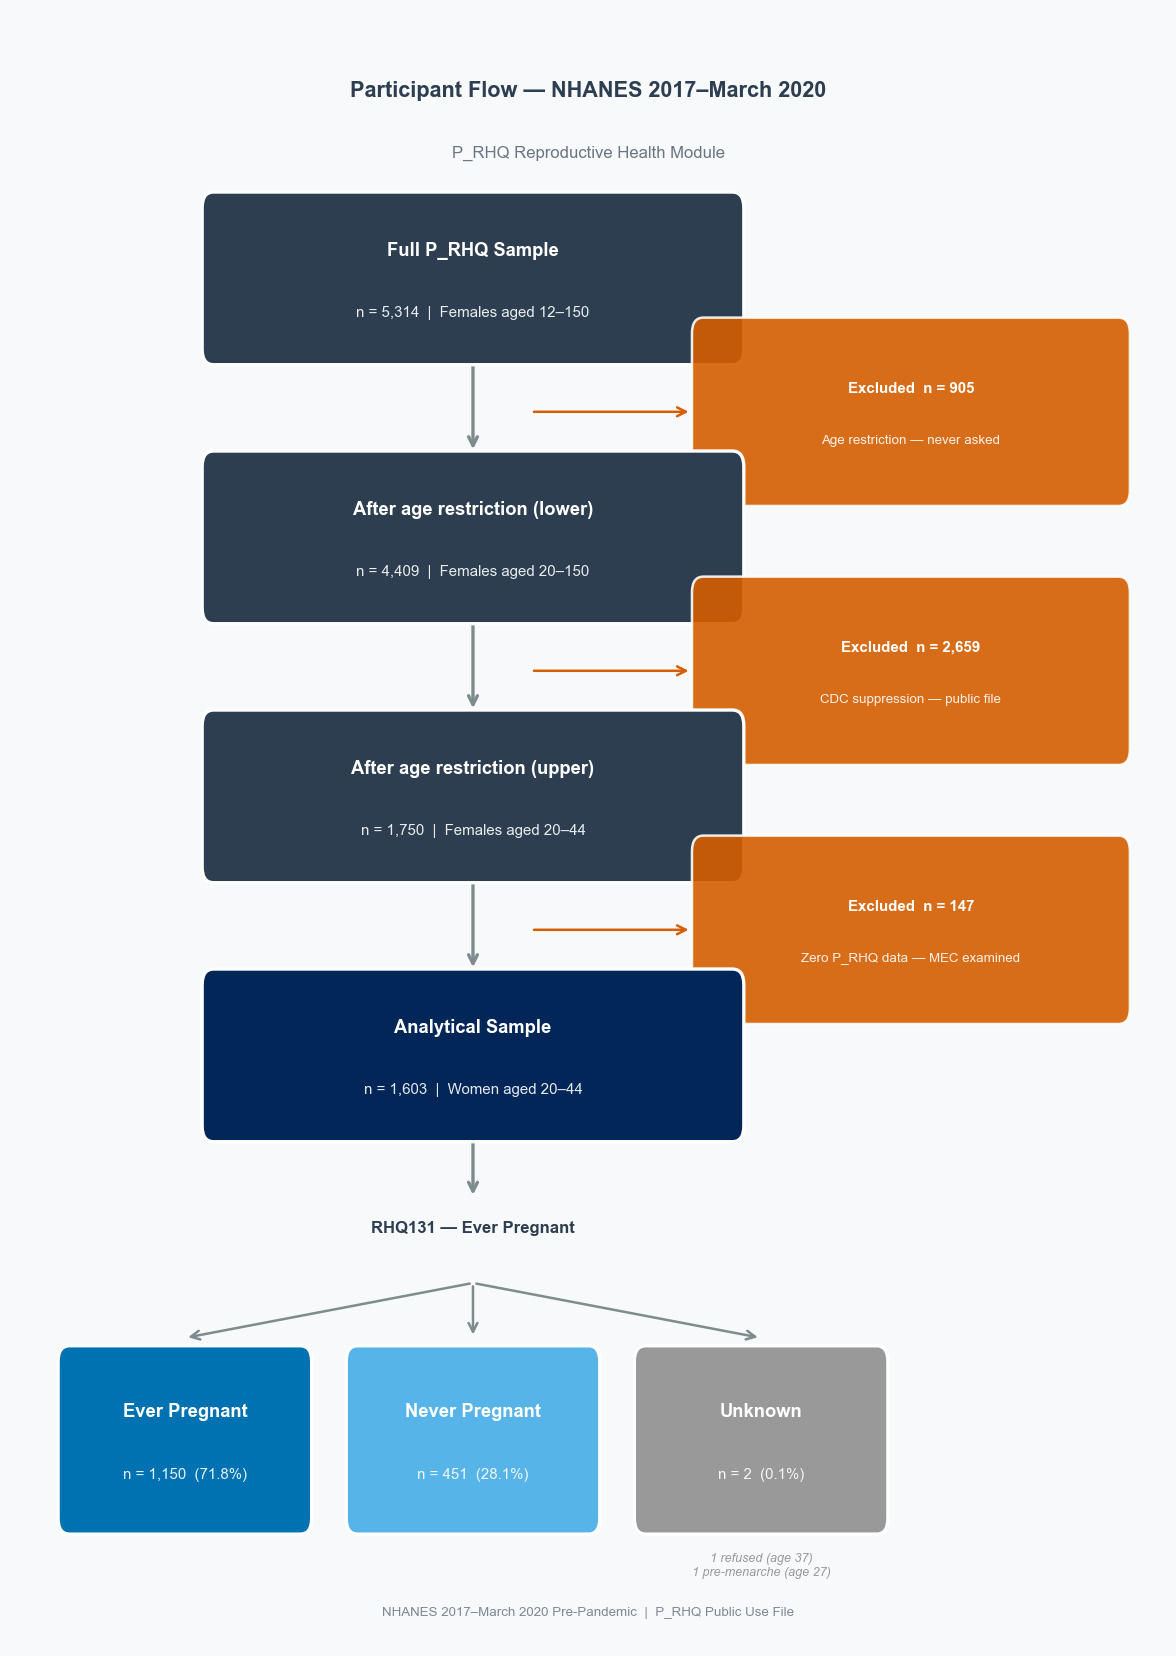

✓ Participant flow diagram saved to ../figures/participant_flow.png


In [328]:
# ── Participant flow diagram ───────────────────────────────────────────────
os.makedirs('../figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 14))
ax.set_xlim(0, 10)
ax.set_ylim(3.6, 14)
ax.axis('off')

# ── Colorblind-safe palette (Okabe-Ito) ───────────────────────────────────
C_MAIN     = '#2C3E50'   # dark navy — main flow boxes
C_EXCLUDE  = '#D55E00'   # vermillion — exclusion boxes (distinct from blue)
C_FINAL    = '#022658'   # blue — analytical sample
C_PREGNANT = '#0072B2'   # blue — ever pregnant
C_NEVER    = '#56B4E9'   # sky blue — never pregnant
C_UNKNOWN  = '#999999'   # grey — unknown
C_ARROW    = '#7F8C8D'   # grey — arrows
C_TEXT     = '#FFFFFF'   # white — box text
C_BG       = '#F8F9FA'   # light grey — background

fig.patch.set_facecolor(C_BG)
ax.set_facecolor(C_BG)

def draw_box(ax, x, y, w, h, text, subtext=None, color=C_MAIN, fontsize=11):
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.1',
        facecolor=color,
        edgecolor='white',
        linewidth=2,
        zorder=3
    )
    ax.add_patch(box)
    if subtext:
        ax.text(x, y + 0.18, text, ha='center', va='center',
                color=C_TEXT, fontsize=fontsize, fontweight='bold', zorder=4)
        ax.text(x, y - 0.22, subtext, ha='center', va='center',
                color=C_TEXT, fontsize=fontsize - 2, zorder=4, alpha=0.9)
    else:
        ax.text(x, y, text, ha='center', va='center',
                color=C_TEXT, fontsize=fontsize, fontweight='bold', zorder=4)

def draw_arrow(ax, x, y_start, y_end, color=C_ARROW):
    ax.annotate('',
                xy=(x, y_end + 0.14),
                xytext=(x, y_start - 0.05),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0),
                zorder=2)

def draw_exclusion(ax, x_main, y, x_excl, label, n, reason):
    ax.annotate('',
                xy=(x_excl - 1.9, y),
                xytext=(x_main + 0.5, y),
                arrowprops=dict(arrowstyle='->', color=C_EXCLUDE, lw=1.5),
                zorder=2)
    box = FancyBboxPatch(
        (x_excl - 1.8, y - 0.5), 3.6, 1.0,
        boxstyle='round,pad=0.1',
        facecolor=C_EXCLUDE,
        edgecolor='white',
        linewidth=1.5,
        zorder=3,
        alpha=0.9
    )
    ax.add_patch(box)
    ax.text(x_excl, y + 0.15, f'Excluded  n = {n:,}',
            ha='center', va='center',
            color=C_TEXT, fontsize=9, fontweight='bold', zorder=4)
    ax.text(x_excl, y - 0.18, reason,
            ha='center', va='center',
            color=C_TEXT, fontsize=8, zorder=4, alpha=0.9)

# ── Title ──────────────────────────────────────────────────────────────────
ax.text(5, 13.5, 'Participant Flow — NHANES 2017–March 2020',
        ha='center', va='center',
        color=C_MAIN, fontsize=13, fontweight='bold')
ax.text(5, 13.1, 'P_RHQ Reproductive Health Module',
        ha='center', va='center',
        color=C_MAIN, fontsize=10, alpha=0.7)

# ── Box 1: Full P_RHQ sample ───────────────────────────────────────────────
draw_box(ax, 4, 12.3, 4.5, 0.9,
         'Full P_RHQ Sample',
         'n = 5,314  |  Females aged 12–150')

draw_arrow(ax, 4, 11.85, 11.05)
draw_exclusion(ax, 4, 11.45, 7.8, 'Age < 20', 905,
               'Age restriction — never asked')

# ── Box 2 ─────────────────────────────────────────────────────────────────
draw_box(ax, 4, 10.65, 4.5, 0.9,
         'After age restriction (lower)',
         'n = 4,409  |  Females aged 20–150')

draw_arrow(ax, 4, 10.2, 9.4)
draw_exclusion(ax, 4, 9.8, 7.8, 'Age > 44', 2659,
               'CDC suppression — public file')

# ── Box 3 ─────────────────────────────────────────────────────────────────
draw_box(ax, 4, 9.0, 4.5, 0.9,
         'After age restriction (upper)',
         'n = 1,750  |  Females aged 20–44')

draw_arrow(ax, 4, 8.55, 7.75)
draw_exclusion(ax, 4, 8.15, 7.8, 'Non-response', 147,
               'Zero P_RHQ data — MEC examined')

# ── Box 4: Analytical sample ───────────────────────────────────────────────
draw_box(ax, 4, 7.35, 4.5, 0.9,
         'Analytical Sample',
         'n = 1,603  |  Women aged 20–44',
         color=C_FINAL)

# Arrow down to RHQ131 label
draw_arrow(ax, 4, 6.9, 6.3)

# ── RHQ131 label ────────────────────────
ax.text(4, 6.25, 'RHQ131 — Ever Pregnant',
        ha='center', va='center',
        color=C_MAIN, fontsize=10, fontweight='bold')

# ── Three branching arrows ─────────────────────────────────────────────────
for x_dest in [1.5, 4.0, 6.5]:
    ax.annotate('',
                xy=(x_dest, 5.55),
                xytext=(4, 5.9),
                arrowprops=dict(arrowstyle='->', color=C_ARROW, lw=1.5),
                zorder=2)

# ── Bottom three boxes — moved down ───────────────────────────────────────
draw_box(ax, 1.5, 4.9, 2, 1.0,
         'Ever Pregnant',
         'n = 1,150  (71.8%)',
         color=C_PREGNANT, fontsize=11)

draw_box(ax, 4.0, 4.9, 2, 1.0,
         'Never Pregnant',
         'n = 451  (28.1%)',
         color=C_NEVER, fontsize=11)

draw_box(ax, 6.5, 4.9, 2, 1.0,
         'Unknown',
         'n = 2  (0.1%)',
         color=C_UNKNOWN, fontsize=11)

# ── NaN footnote ───────────────────────────────────────────────────────────
ax.text(6.5, 4.1, '1 refused (age 37)\n1 pre-menarche (age 27)',
        ha='center', va='center',
        color=C_UNKNOWN, fontsize=7.5, style='italic')

# ── Source note ────────────────────────────────────────────────────────────
ax.text(5, 3.8,
        'NHANES 2017–March 2020 Pre-Pandemic  |  P_RHQ Public Use File',
        ha='center', va='center',
        color=C_MAIN, fontsize=8, alpha=0.6)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/participant_flow.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print('✓ Participant flow diagram saved to ../figures/participant_flow.png')

### Known limitations
- Women 45+ excluded — pregnancy data suppressed in public use file
- 148 women aged 20–44 excluded — module non-response, cannot be recovered
- 5 women with unknown pregnancy status retained — contribute to 
  non-pregnancy analyses only
- Weighted prevalence estimates are point estimates only — no confidence 
  intervals in current implementation
- All P_RHQ data is self-reported — recall bias applies throughout
- RHQ163, RHQ166, RHQ169 absent from this public release — hypertensive 
  disorders of pregnancy and excess gestational weight gain cannot be derived

### Output files

| File | Shape | Description |
|---|---|---|
| `nhanes_clean_sample.csv` | 1,603 × 43 | Primary input for notebook 02 |
| `sample_characterization.csv` | 5 × 4 | Exclusion flow reference |
| `prevalence_estimates.csv` | 10 × 6 | Weighted/unweighted prevalence |

### What notebook 02 will do
Notebook 02 begins feature engineering from `nhanes_clean_sample.csv`. 
The first task is applying `recode_yes_no()` permanently to all binary 
variables — deferred from this notebook to preserve the boundary between 
exploration and engineering. Subsequent tasks cover four reproductive 
domains: pregnancy history, adverse pregnancy outcomes, surgical history, 
and hormone therapy. All decisions affecting feature construction are 
documented at the start of notebook 02.

### Planned upgrade
The weighted prevalence implementation will be upgraded from 
`numpy.average()` to a full complex survey design using the R `survey` 
package via rpy2. This will add standard errors and 95% confidence 
intervals to all prevalence estimates. Implementation is deferred until 
the full pipeline is complete.

---
*NHANES 2017–March 2020 Pre-Pandemic | P_RHQ Reproductive Health Module*  
*Analytical sample: 1,603 women aged 20–44*  
*Last updated: 2026*